# EDA on E-Commerce Sales & Customer Analytics

### Name- Aastha Baheti
### Batch- 2
### SAP ID- 590012973

**Dataset:** `ecommerce_sales_customer_analytics_150k.csv`
- **Name:**  E-Commerce Sales Analytics Dataset — 150K+ Transactions | 2021–2025

- **Source:** Kaggle — https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics?resource=download




# 1. IMPORT LIBRARIES



In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions
from scipy import stats

# Optional interactive visualization
import plotly.express as px


# Plot settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)




# 2. LOAD DATASET



In [2]:


file_path = "ecommerce_sales_customer_analytics_150k.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])




DATASET LOADED
Shape: (138116, 46)
Rows: 138116
Columns: 46


# 4. Dataset structure



In [3]:



print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- LAST 5 ROWS ---")
print(df.tail())

print("\n--- RANDOM 5 ROWS ---")
print(df.sample(5, random_state=42))

print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())

print("\n--- DATASET INFORMATION ---")
df.info()

print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- SHAPE ---")
print(df.shape)

print("\n--- NUMERICAL DESCRIPTIVE STATISTICS ---")
print(df.describe())

print("\n--- ALL DESCRIPTIVE STATISTICS ---")
print(df.describe(include="all").T)




--- FIRST 5 ROWS ---
     order_id  order_date order_time order_status sales_channel  customer_id  \
0  ORD-301242  2023-11-06   16:37:47    Completed    Mobile App  CUST-003102   
1  ORD-773460  2025-12-24   01:22:36    Completed       Website  CUST-003124   
2  ORD-449374  2021-07-05   14:24:21    Completed    Mobile App  CUST-012496   
3  ORD-567636  2023-01-21   07:20:26    Completed  Social Media  CUST-023928   
4  ORD-820028  2022-05-13   09:46:21    Completed  Social Media  CUST-012730   

    customer_name  customer_age  gender customer_segment customer_type  \
0    Jasmine Ryan            55    Male         Consumer         Loyal   
1     Scott Chase            26    Male          Premium         Loyal   
2    Marc Wheeler            69  Female          Premium         Loyal   
3  Jennifer Smith            65    Male         Consumer         Loyal   
4    Jessica Wang            34  Female         Consumer         Loyal   

      customer_city     customer_state customer_coun

# 7. DUPLICATE ANALYSIS



In [4]:


duplicate_count = df.duplicated().sum()

print("\n--- DUPLICATE ANALYSIS ---")
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated()].head())

    # Create cleaned copy without duplicates
    df_clean = df.drop_duplicates().copy()
else:
    print("No duplicate rows found.")
    df_clean = df.copy()





--- DUPLICATE ANALYSIS ---
Number of duplicate rows: 0
No duplicate rows found.


# 8. MISSING VALUE ANALYSIS



In [7]:


print("\n--- MISSING VALUES ---")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percent
})

missing_table = missing_table.sort_values(
    "Missing_Percentage",
    ascending=False
)

print(missing_table[missing_table["Missing_Count"] > 0])









--- MISSING VALUES ---
                         Missing_Count  Missing_Percentage
return_reason                   128654           93.149237
return_status                   128654           93.149237
coupon_code                     110502           80.006661
campaign_name                    83233           60.263112
customer_review                  24557           17.779982
customer_rating                  24557           17.779982
estimated_delivery_days          24557           17.779982
delivery_days                    24557           17.779982
review_sentiment                 24557           17.779982


# 11. DATA CONSISTENCY CHECKS



In [9]:


print("\n--- DATA CONSISTENCY CHECKS ---")

# Check age
if "customer_age" in df.columns:
    print(
        "Invalid ages:",
        ((df["customer_age"] < 0) | (df["customer_age"] > 120)).sum()
    )

# Check quantity
if "quantity" in df.columns:
    print(
        "Invalid/non-positive quantities:",
        (df["quantity"] <= 0).sum()
    )

# Check negative sales
for col in ["gross_sales", "net_sales", "product_cost", "shipping_cost"]:
    if col in df.columns:
        print(
            f"Negative values in {col}:",
            (df[col] < 0).sum()
        )

# Check negative profit separately
if "profit" in df.columns:
    print(
        "Negative profit values:",
        (df["profit"] < 0).sum()
    )

# Check percentage range
if "profit_margin_percentage" in df.columns:
    print(
        "Profit margin outside -100 to 100:",
        (
            (df["profit_margin_percentage"] < -100) |
            (df["profit_margin_percentage"] > 100)
        ).sum()
    )





--- DATA CONSISTENCY CHECKS ---
Invalid ages: 0
Invalid/non-positive quantities: 0
Negative values in gross_sales: 0
Negative values in net_sales: 0
Negative values in product_cost: 0
Negative values in shipping_cost: 0
Negative profit values: 1296
Profit margin outside -100 to 100: 0


# 12. DATE AND TIME ANALYSIS



In [10]:


if "order_date" in df.columns:

    df_clean["order_date"] = pd.to_datetime(
        df_clean["order_date"],
        errors="coerce"
    )

    df_clean["order_year"] = df_clean["order_date"].dt.year
    df_clean["order_month"] = df_clean["order_date"].dt.month
    df_clean["order_month_name"] = df_clean["order_date"].dt.month_name()
    df_clean["order_day"] = df_clean["order_date"].dt.day
    df_clean["order_day_name"] = df_clean["order_date"].dt.day_name()
    df_clean["order_quarter"] = df_clean["order_date"].dt.quarter

    print("\n--- DATE RANGE ---")
    print("Minimum date:", df_clean["order_date"].min())
    print("Maximum date:", df_clean["order_date"].max())

if "order_time" in df_clean.columns:
    df_clean["order_time"] = pd.to_datetime(
        df_clean["order_time"],
        format="%H:%M:%S",
        errors="coerce"
    ).dt.time

print("\nDate/time columns processed.")





--- DATE RANGE ---
Minimum date: 2021-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00

Date/time columns processed.


# 13. UNIVARIATE ANALYSIS - NUMERICAL VARIABLES



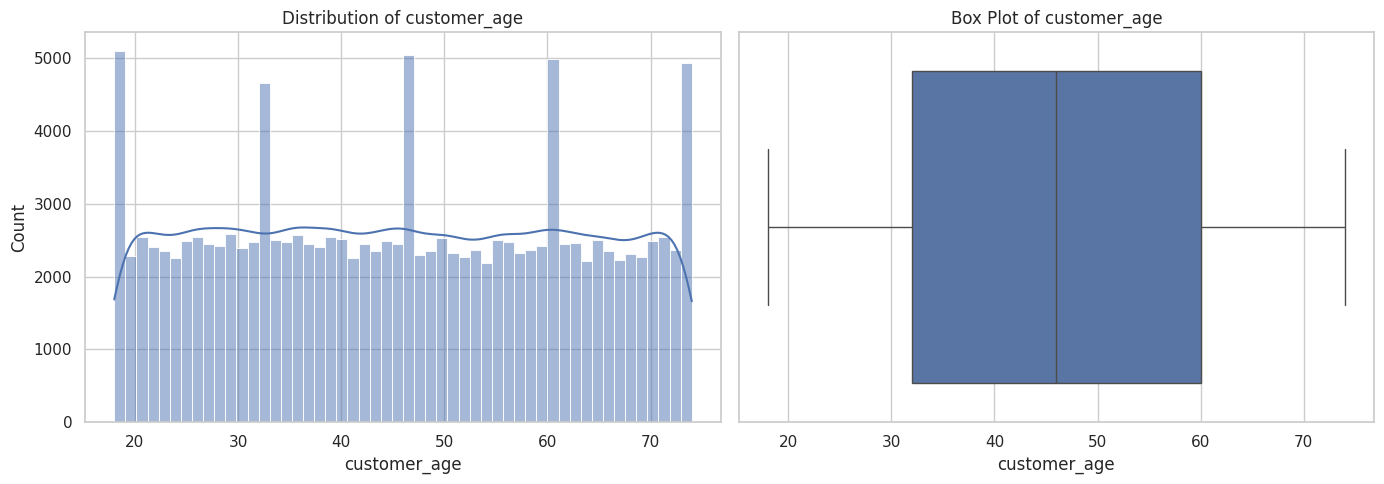

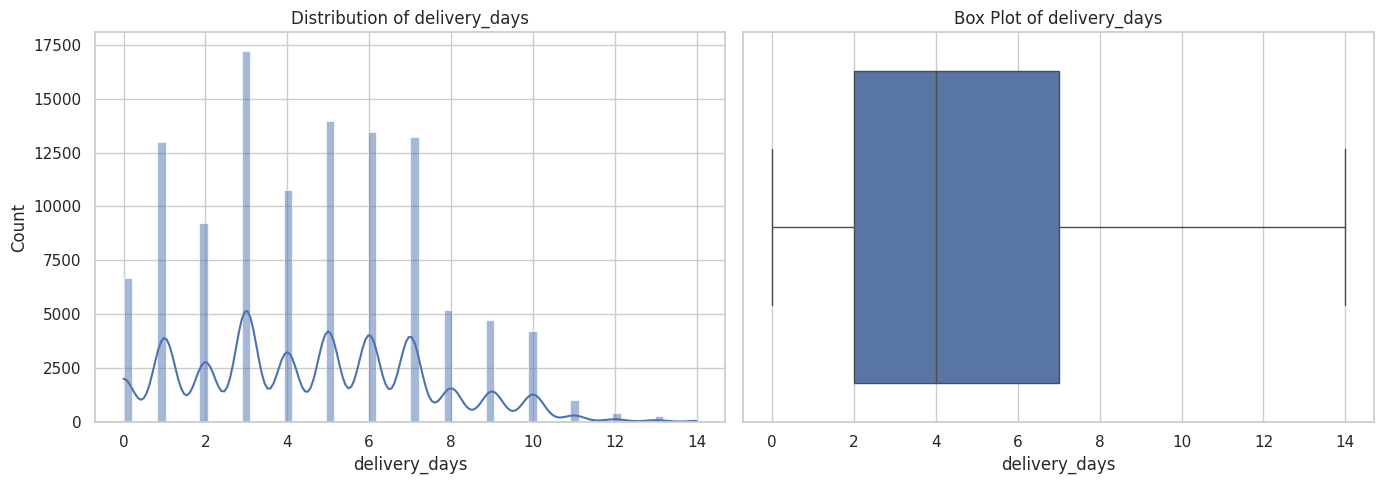

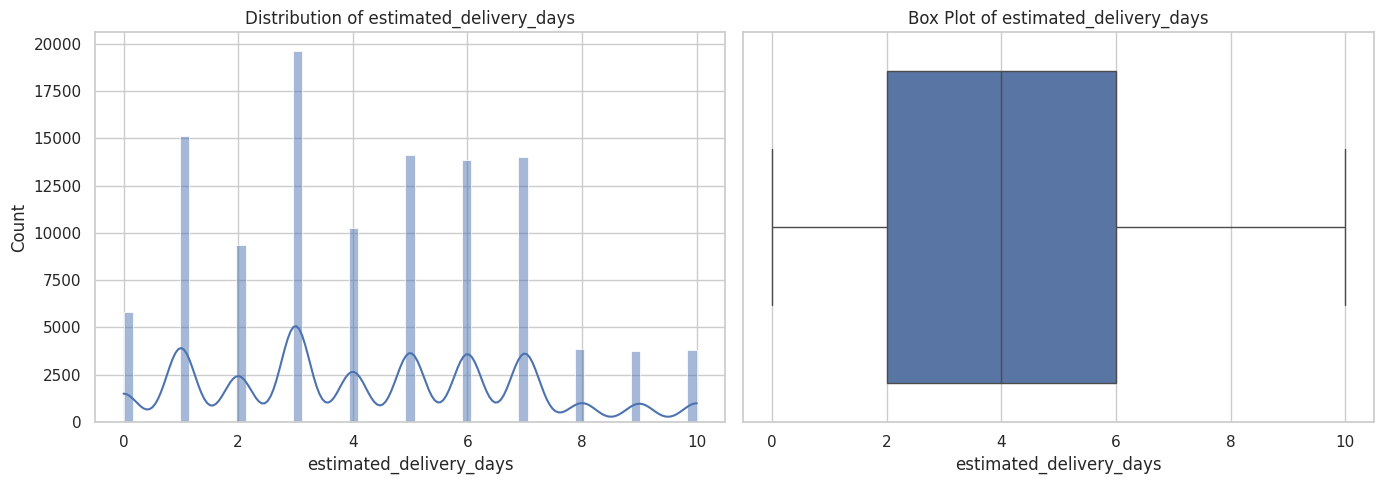

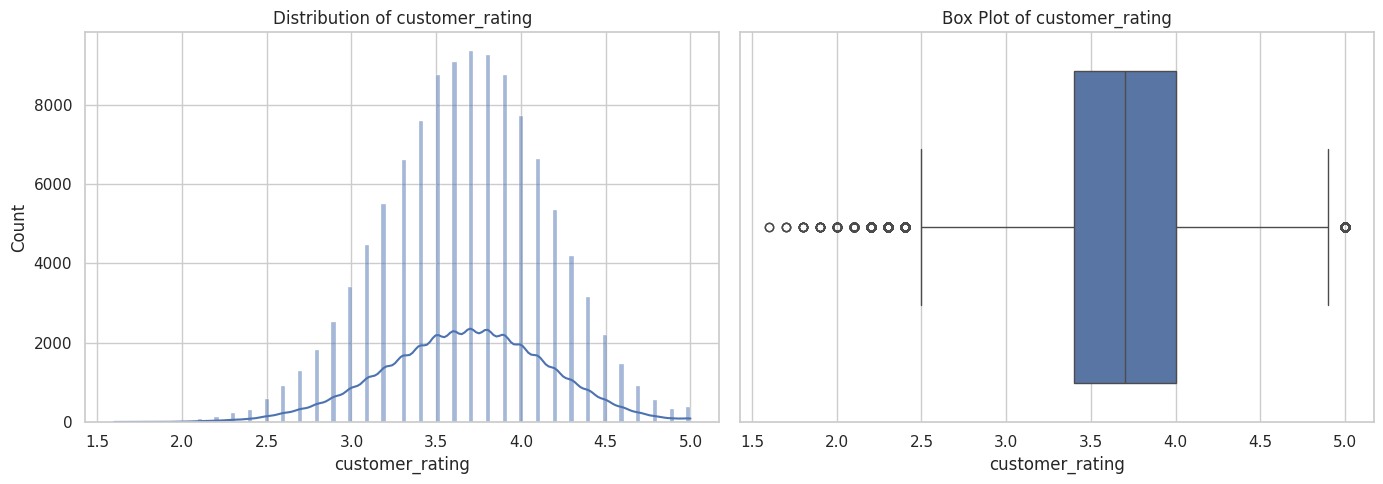

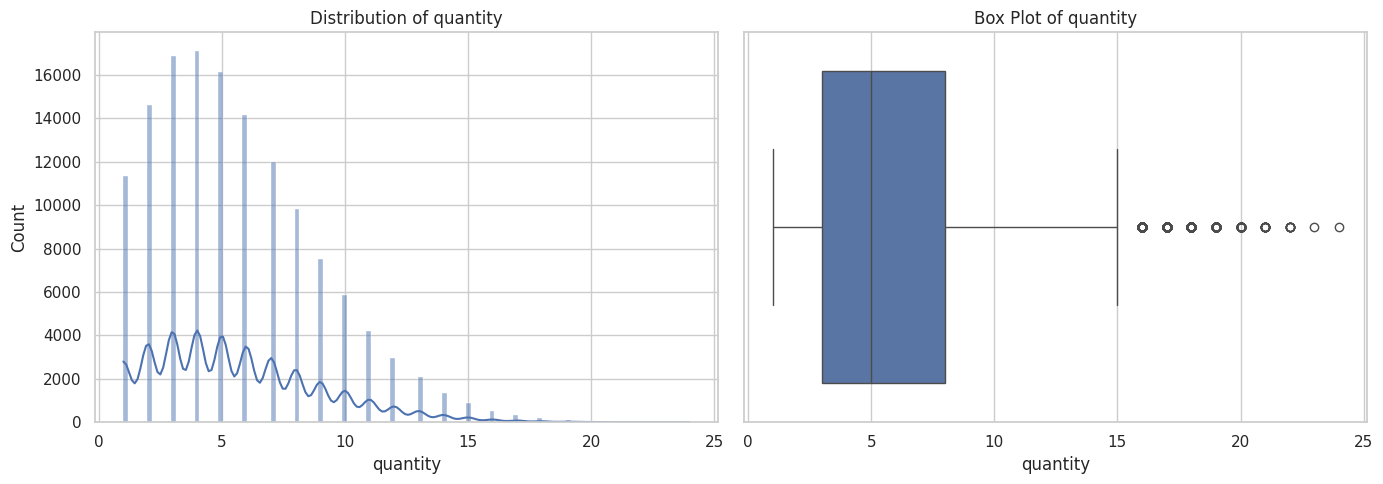

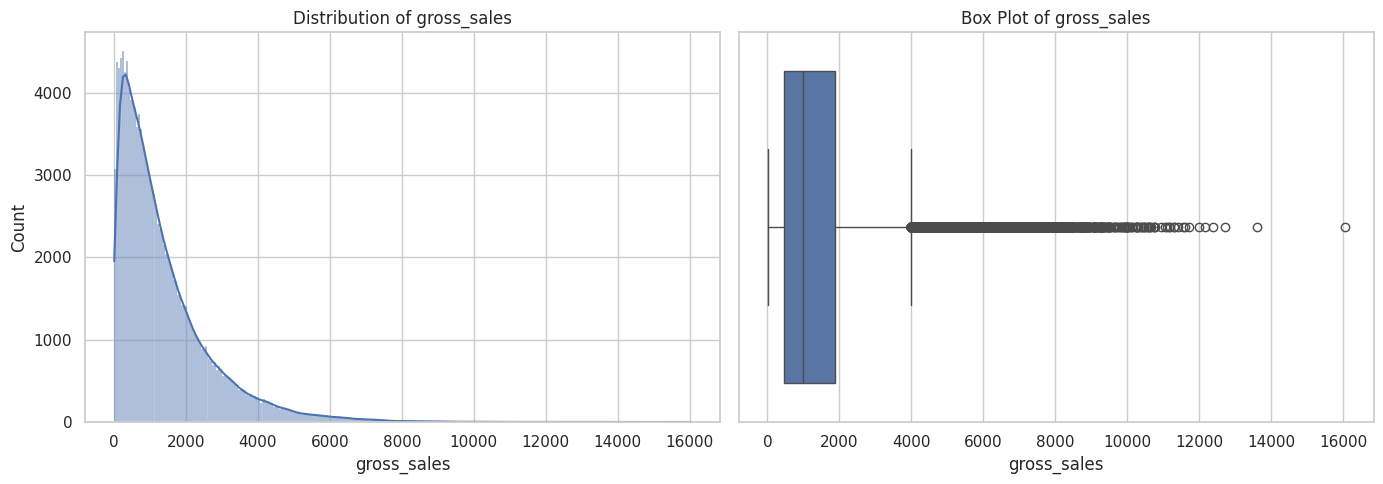

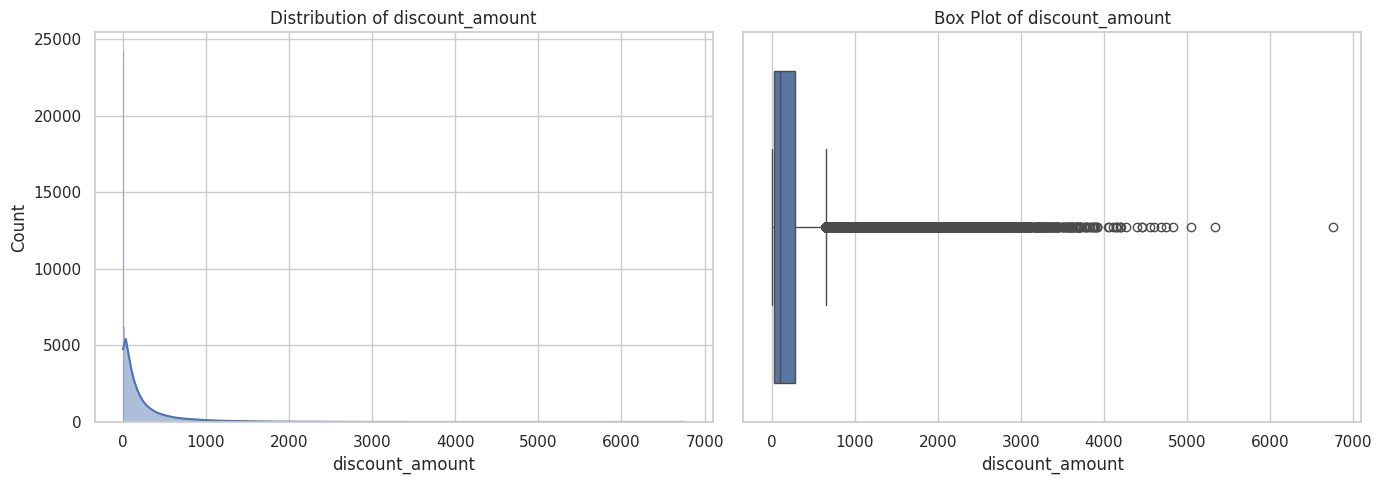

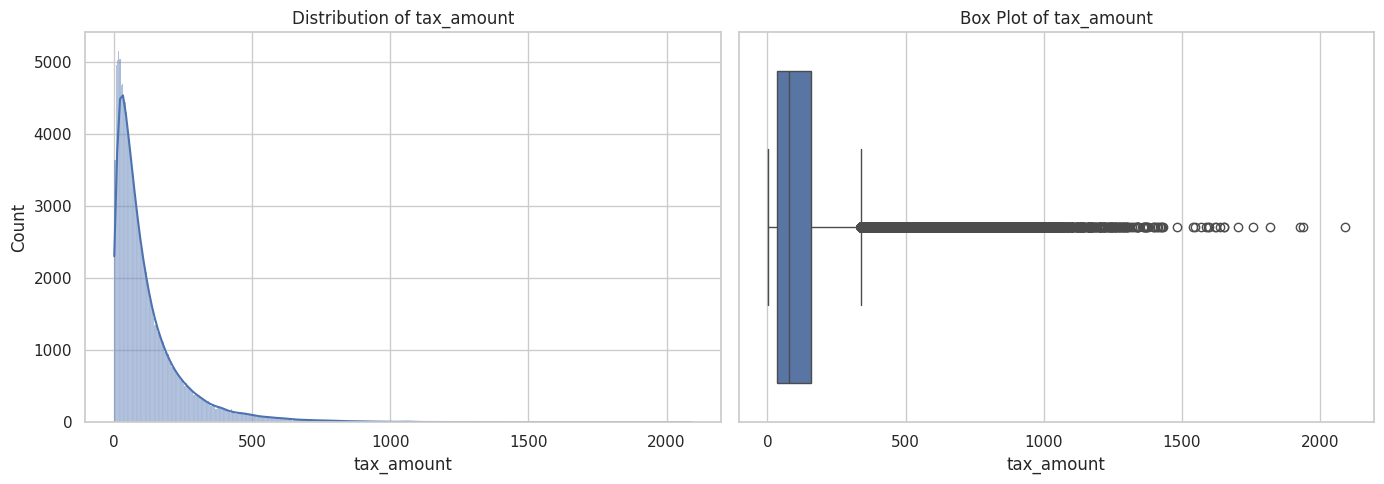

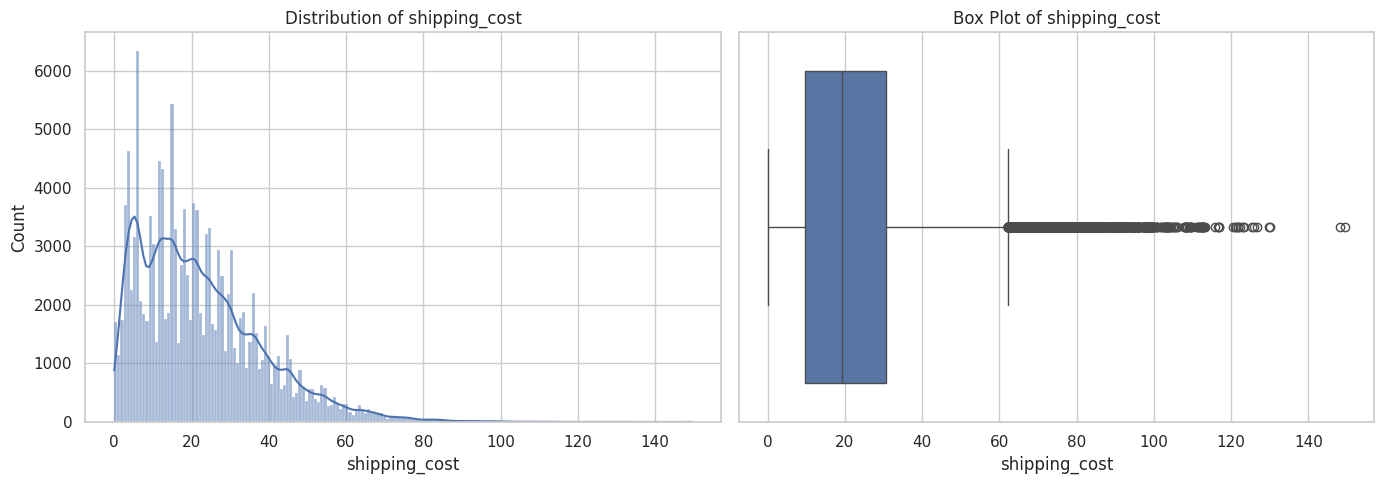

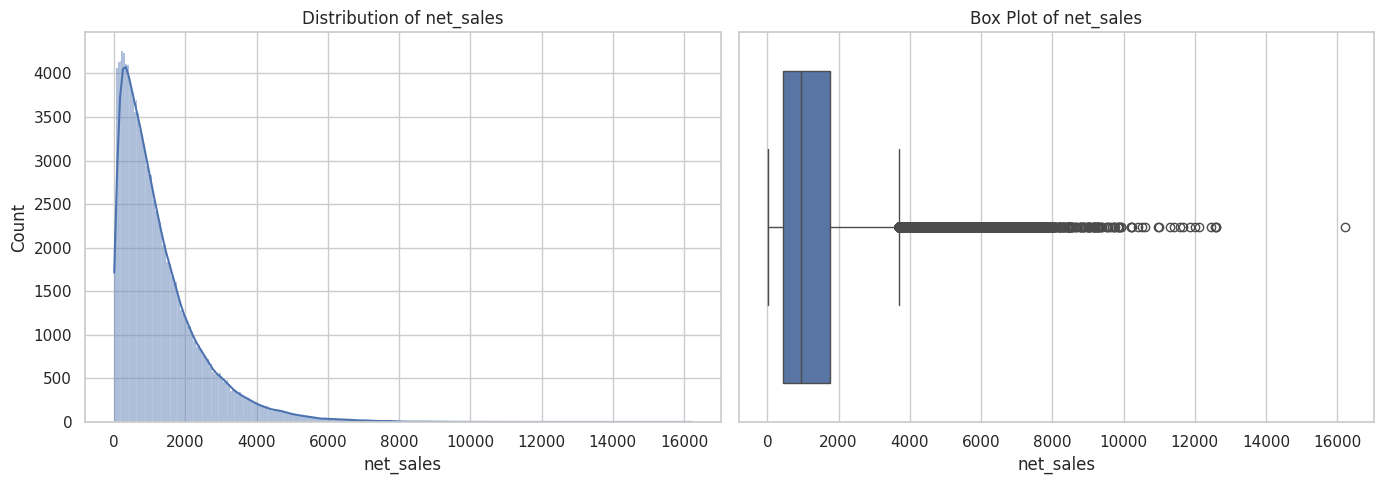

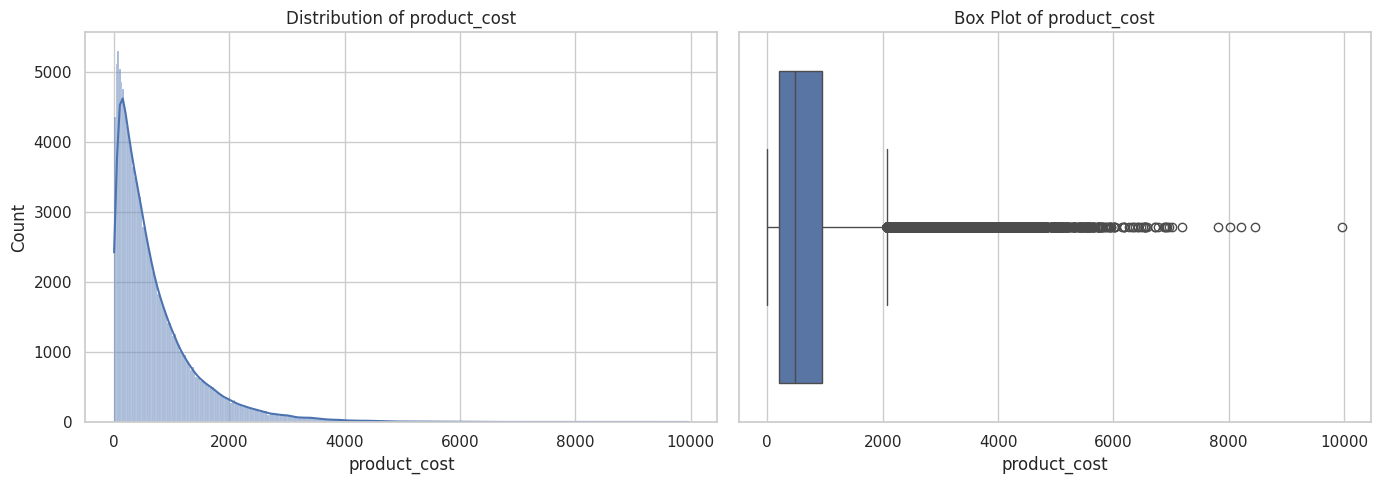

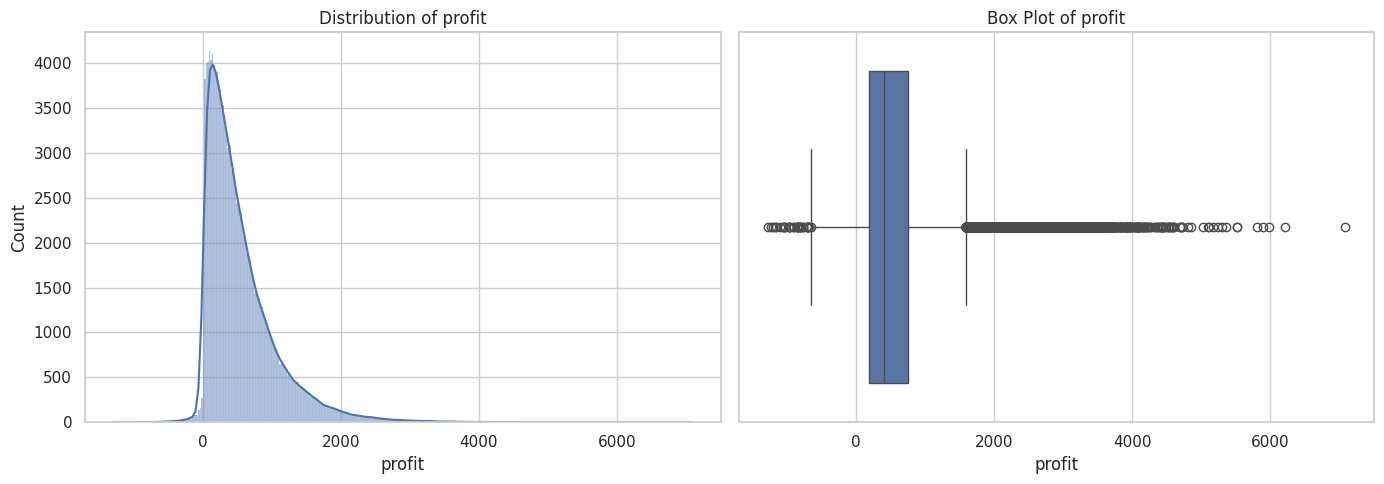

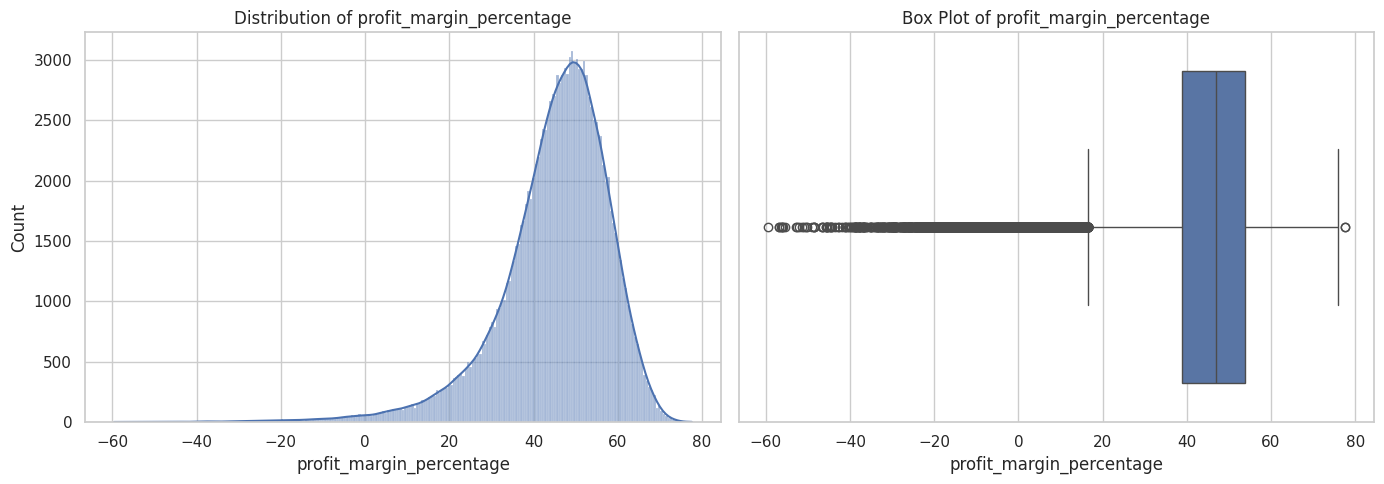

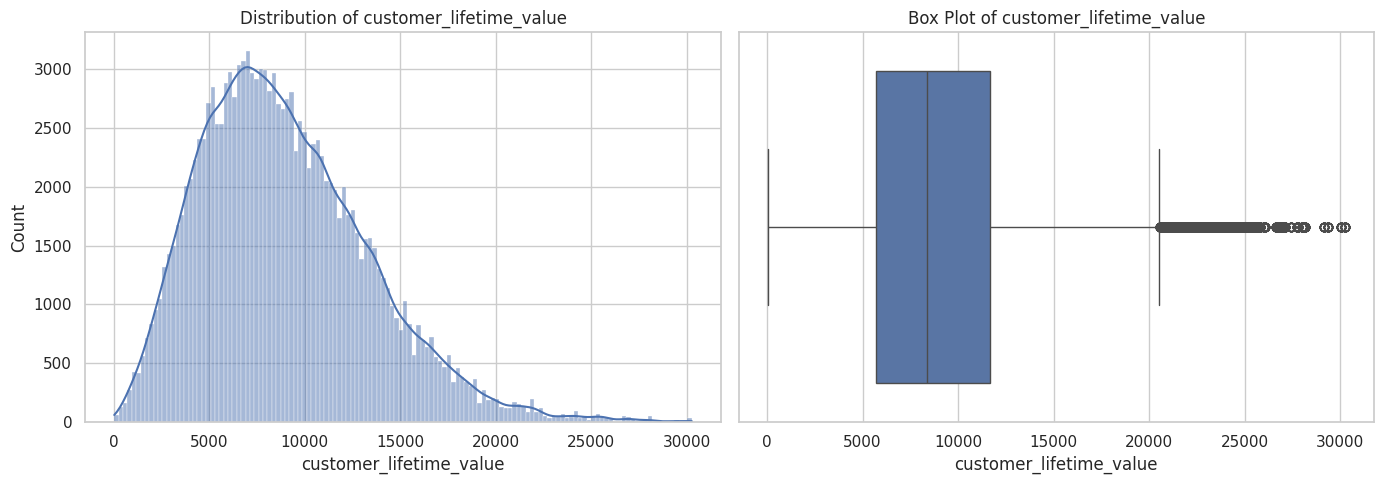

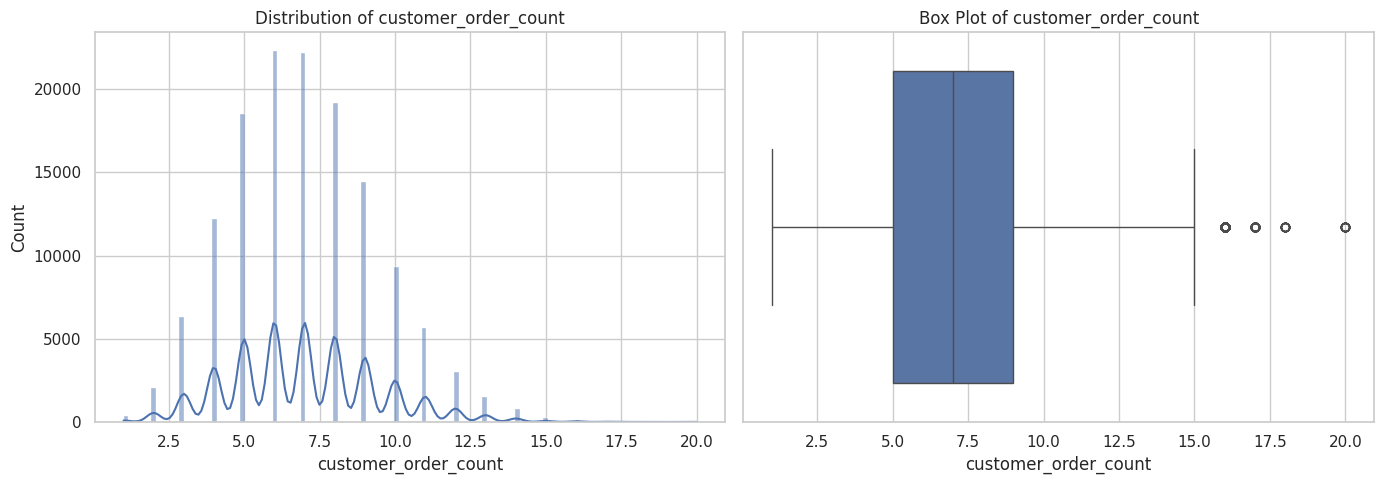

In [11]:


important_numeric = [
    "customer_age",
    "delivery_days",
    "estimated_delivery_days",
    "customer_rating",
    "quantity",
    "gross_sales",
    "discount_amount",
    "tax_amount",
    "shipping_cost",
    "net_sales",
    "product_cost",
    "profit",
    "profit_margin_percentage",
    "customer_lifetime_value",
    "customer_order_count"
]

important_numeric = [
    col for col in important_numeric
    if col in df_clean.columns
]

for col in important_numeric:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram + KDE
    sns.histplot(
        df_clean[col].dropna(),
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {col}")

    # Boxplot
    sns.boxplot(
        x=df_clean[col],
        ax=axes[1]
    )
    axes[1].set_title(f"Box Plot of {col}")

    plt.tight_layout()
    plt.show()




# 14. UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES



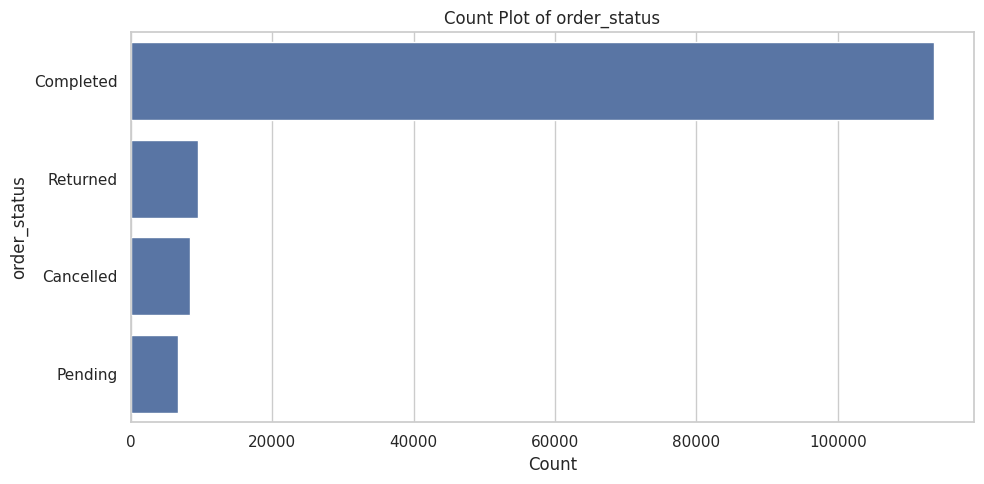

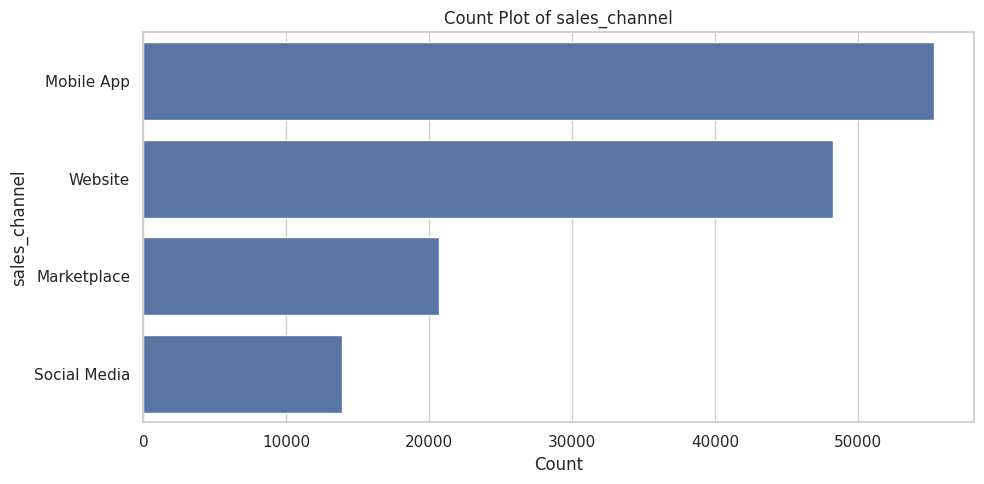

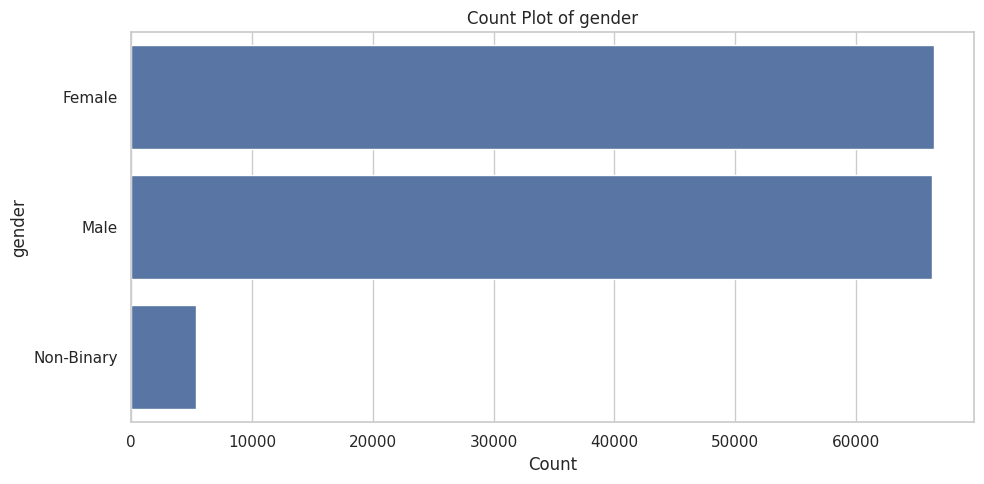

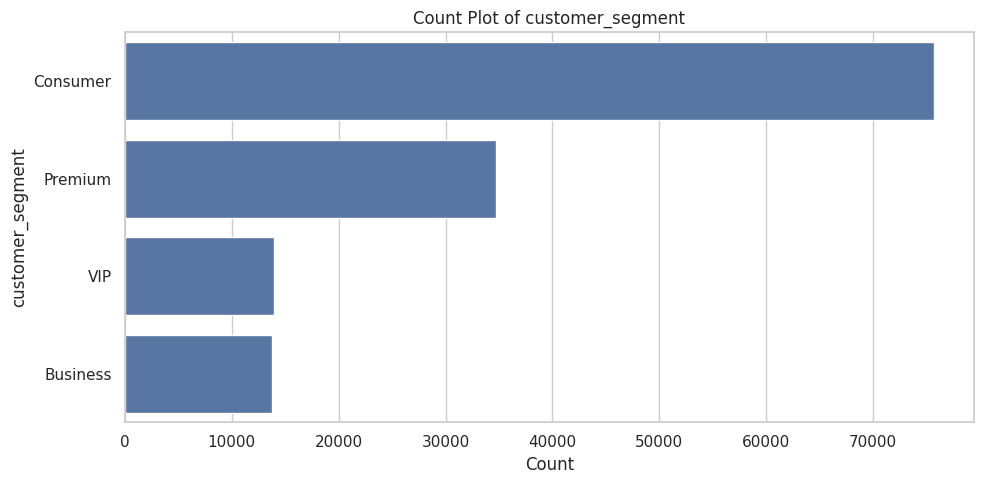

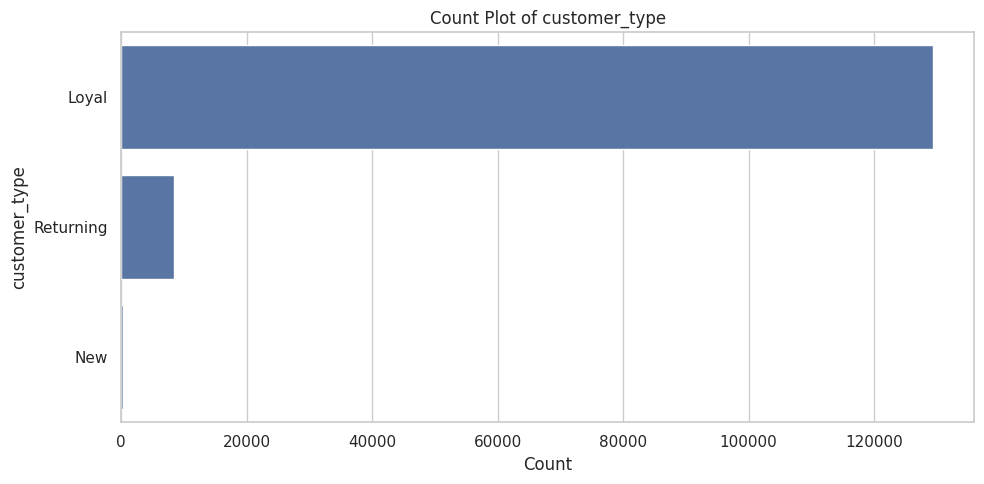

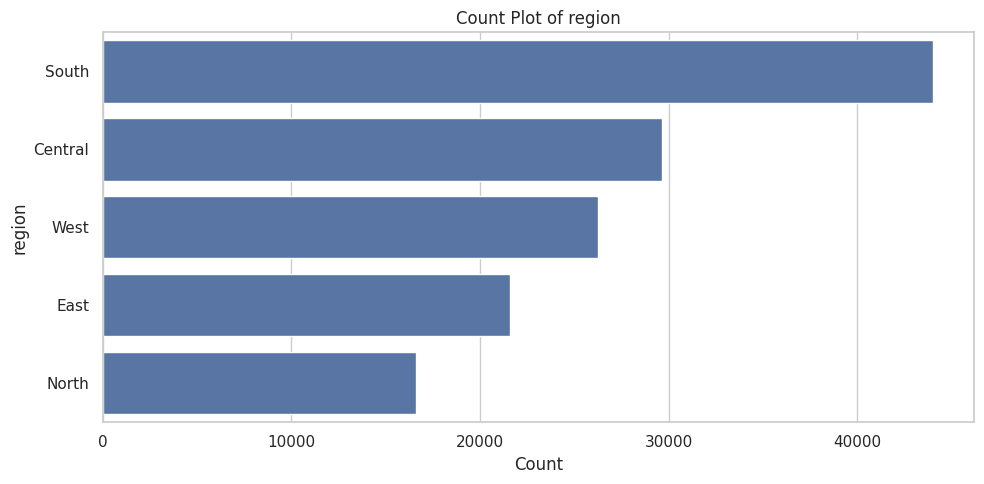

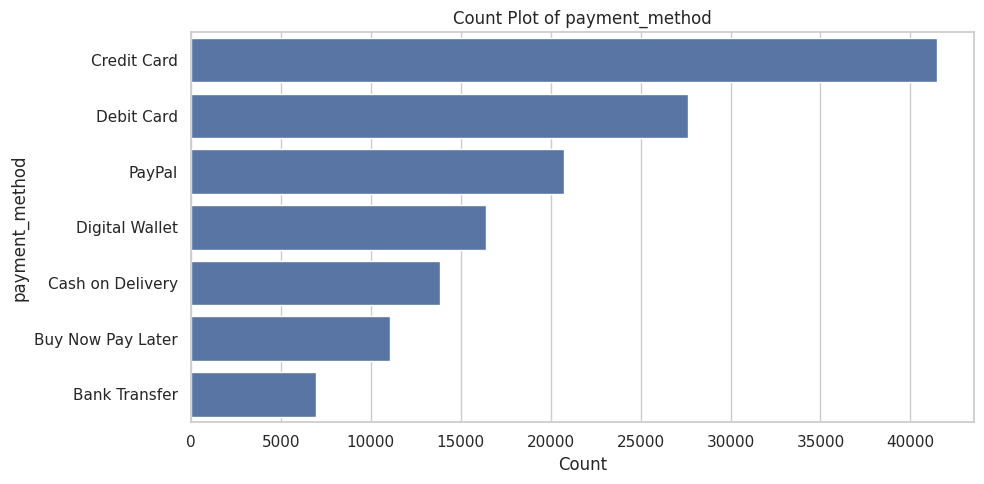

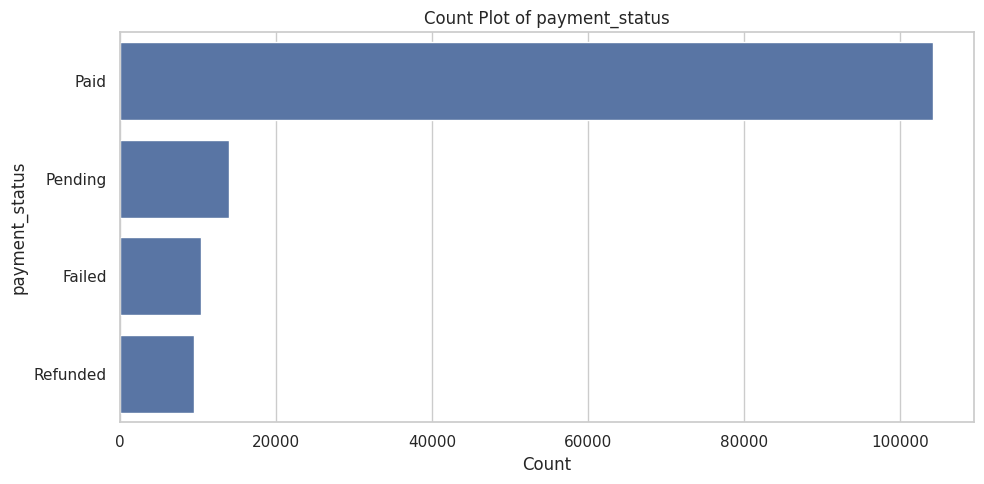

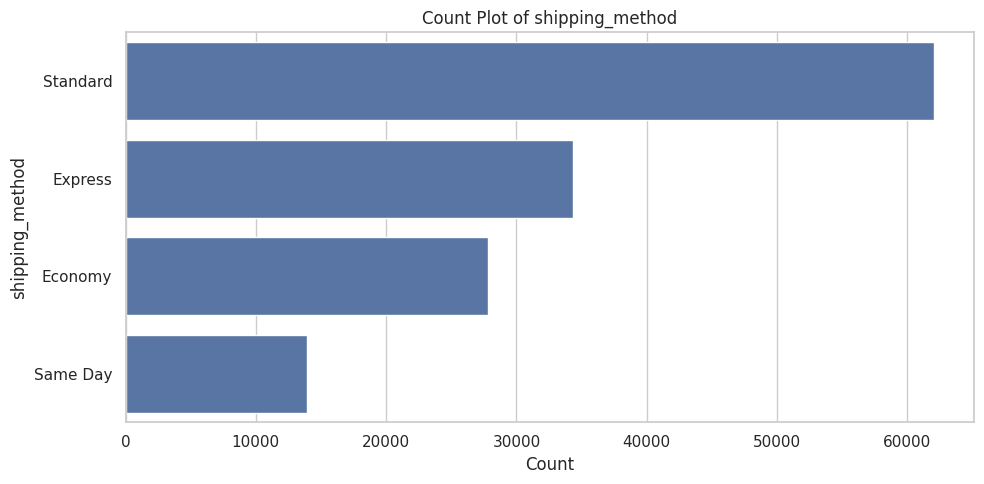

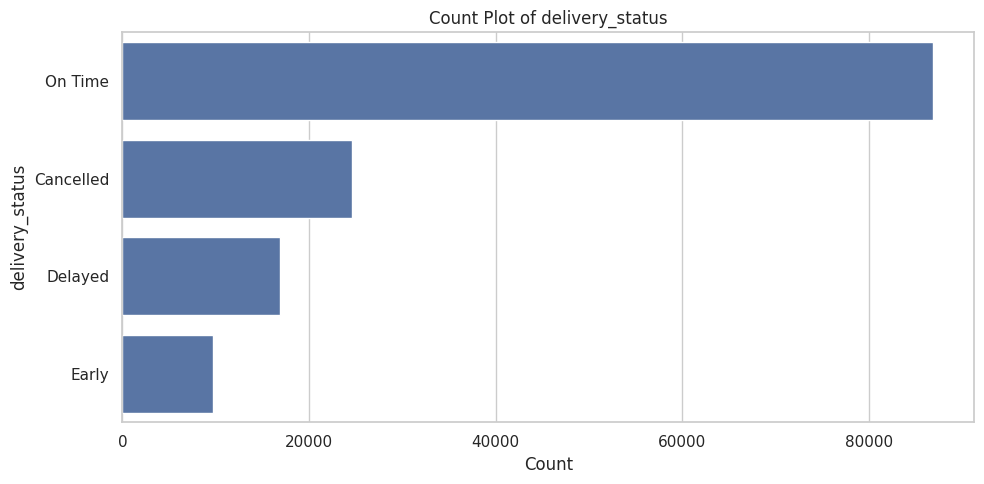

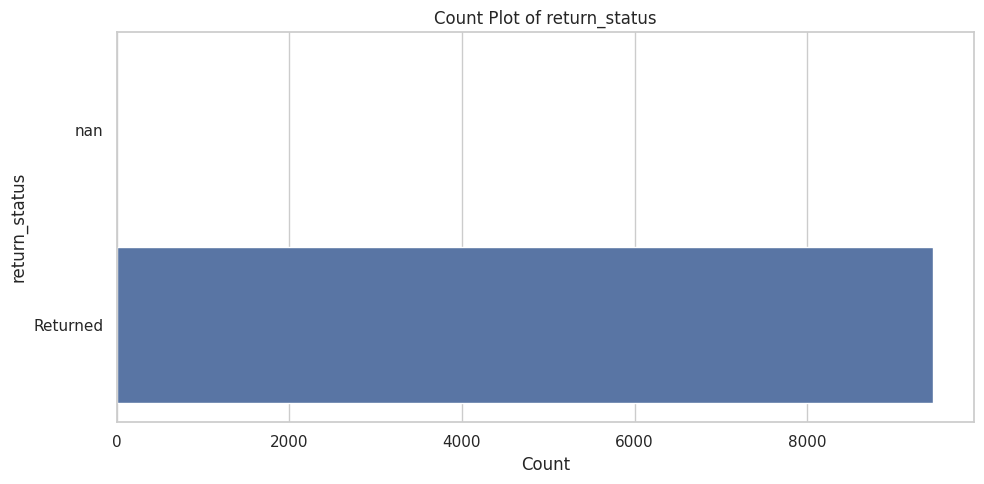

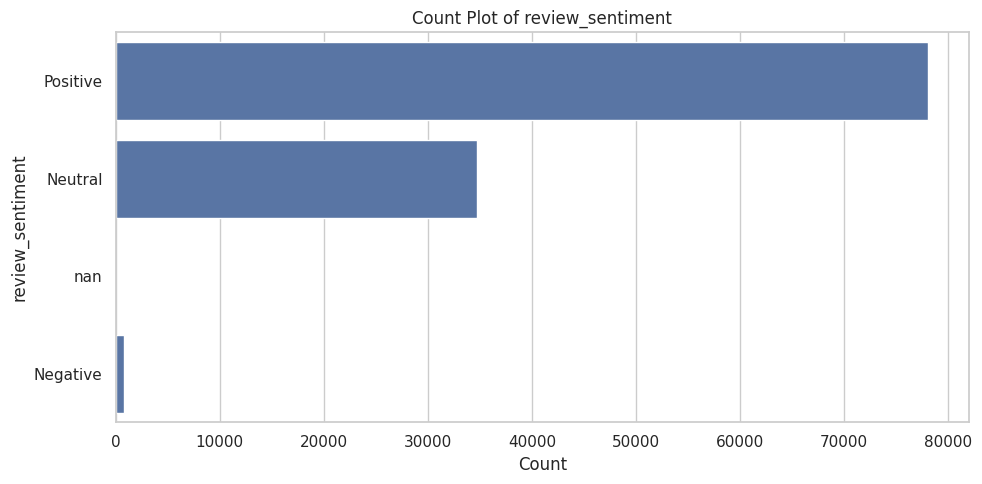

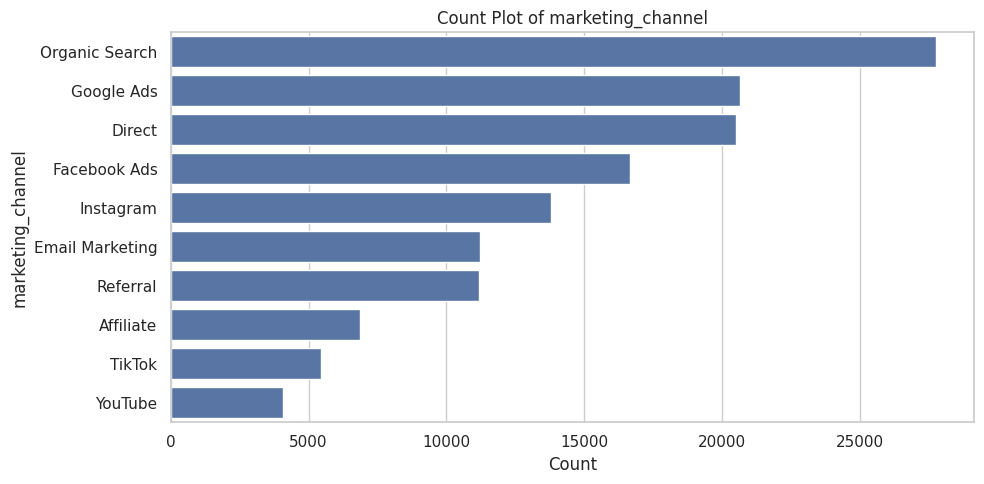

In [12]:


categorical_for_plot = [
    "order_status",
    "sales_channel",
    "gender",
    "customer_segment",
    "customer_type",
    "region",
    "payment_method",
    "payment_status",
    "shipping_method",
    "delivery_status",
    "return_status",
    "review_sentiment",
    "marketing_channel"
]

categorical_for_plot = [
    col for col in categorical_for_plot
    if col in df_clean.columns
]

for col in categorical_for_plot:

    plt.figure(figsize=(10, 5))

    order = df_clean[col].value_counts(dropna=False).index

    sns.countplot(
        data=df_clean,
        y=col,
        order=order
    )

    plt.title(f"Count Plot of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()




# 15. OUTLIER DETECTION USING IQR



In [14]:


print("\n--- OUTLIER ANALYSIS USING IQR ---")

outlier_summary = []

for col in important_numeric:

    series = df_clean[col].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_limit) |
        (series > upper_limit)
    ]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Limit": lower_limit,
        "Upper_Limit": upper_limit,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": len(outliers) / len(series) * 100
    })

outlier_table = pd.DataFrame(outlier_summary)

print(outlier_table.sort_values(
    "Outlier_Count",
    ascending=False
))






--- OUTLIER ANALYSIS USING IQR ---
                      Column         Q1          Q3        IQR  Lower_Limit  \
6            discount_amount    26.3275    277.1250   250.7975   -349.86875   
7                 tax_amount    34.6500    156.2000   121.5500   -147.67500   
10              product_cost   207.6675    953.7625   746.0950   -911.47500   
5                gross_sales   458.9200   1871.2000  1412.2800  -1659.50000   
11                    profit   190.7575    752.8450   562.0875   -652.37375   
9                  net_sales   448.2000   1744.5825  1296.3825  -1496.37375   
12  profit_margin_percentage    38.8800     53.7700    14.8900     16.54500   
8              shipping_cost     9.8200     30.7500    20.9300    -21.57500   
13   customer_lifetime_value  5713.5700  11651.0300  5937.4600  -3192.62000   
4                   quantity     3.0000      8.0000     5.0000     -4.50000   
3            customer_rating     3.4000      4.0000     0.6000      2.50000   
14      customer

# 16. BIVARIATE ANALYSIS



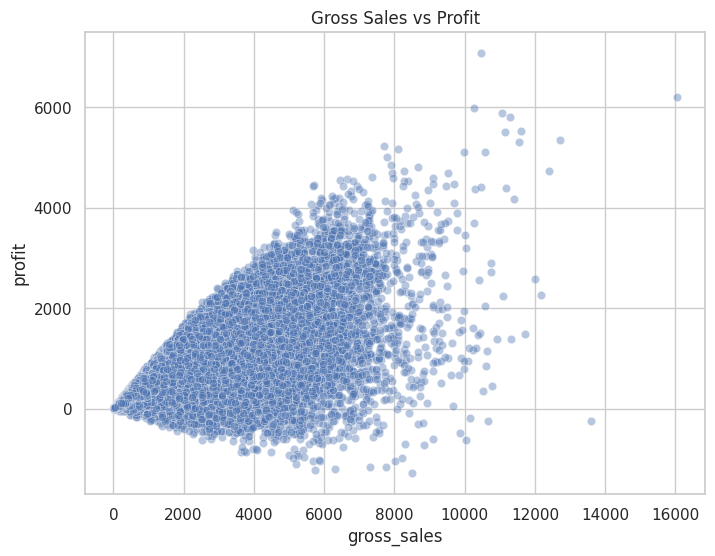

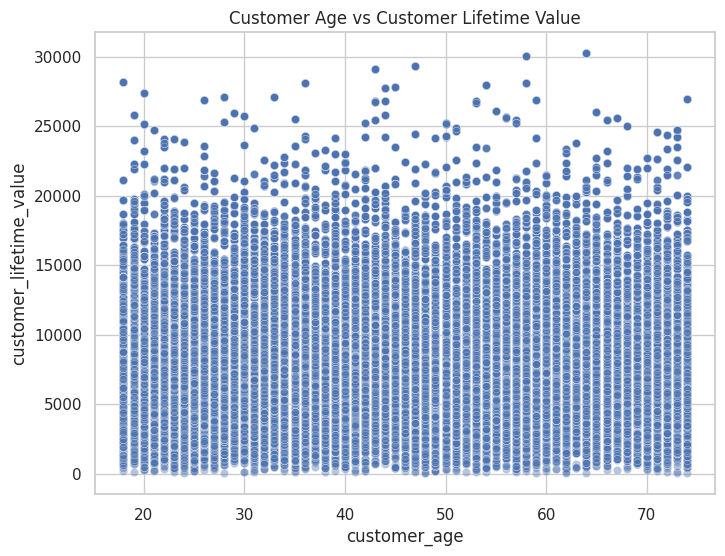

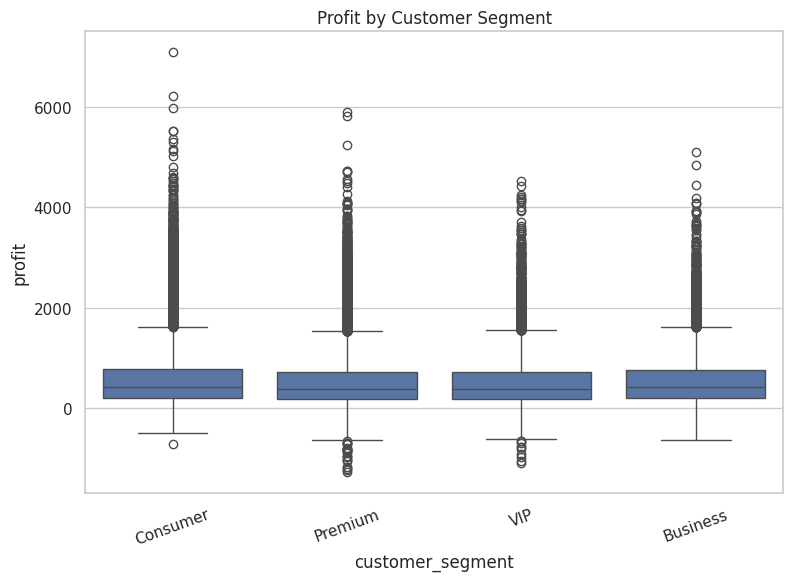

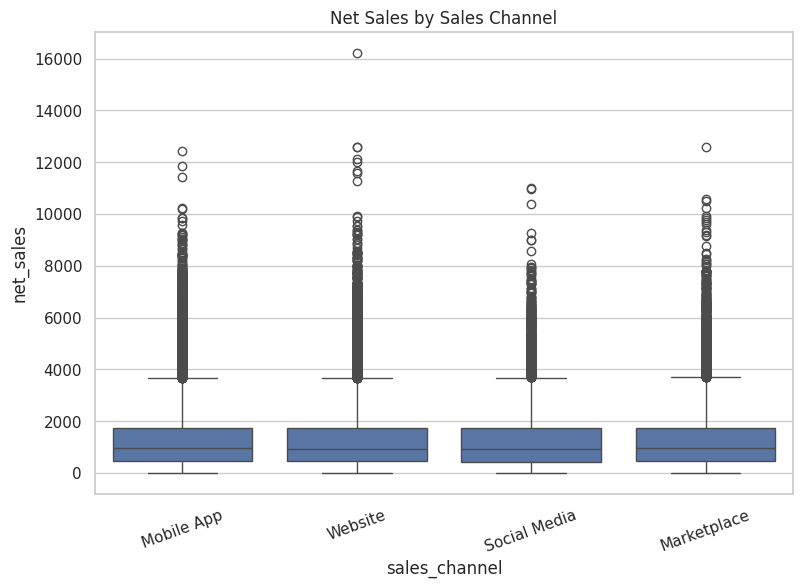


--- GENDER VS CUSTOMER SEGMENT ---
customer_segment  Business  Consumer  Premium   VIP
gender                                             
Female                6526     36835    16532  6546
Male                  6749     35847    16780  6908
Non-Binary             502      2954     1434   503


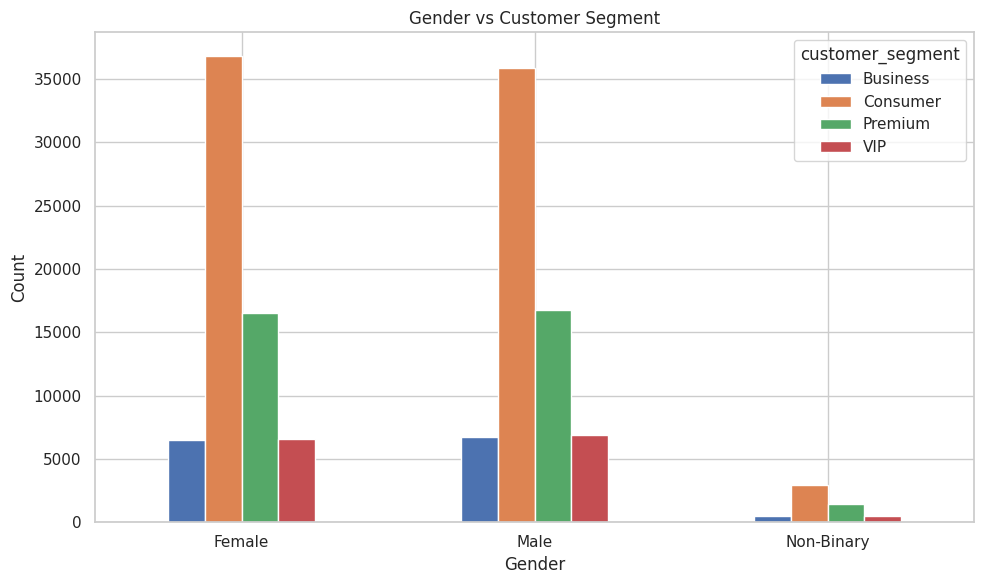

In [15]:


# Numerical vs numerical

if {"gross_sales", "profit"}.issubset(df_clean.columns):

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_clean,
        x="gross_sales",
        y="profit",
        alpha=0.4
    )
    plt.title("Gross Sales vs Profit")
    plt.show()


if {"customer_age", "customer_lifetime_value"}.issubset(df_clean.columns):

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_clean,
        x="customer_age",
        y="customer_lifetime_value",
        alpha=0.4
    )
    plt.title("Customer Age vs Customer Lifetime Value")
    plt.show()


# Categorical vs numerical

if {"customer_segment", "profit"}.issubset(df_clean.columns):

    plt.figure(figsize=(9, 6))
    sns.boxplot(
        data=df_clean,
        x="customer_segment",
        y="profit"
    )
    plt.title("Profit by Customer Segment")
    plt.xticks(rotation=20)
    plt.show()


if {"sales_channel", "net_sales"}.issubset(df_clean.columns):

    plt.figure(figsize=(9, 6))
    sns.boxplot(
        data=df_clean,
        x="sales_channel",
        y="net_sales"
    )
    plt.title("Net Sales by Sales Channel")
    plt.xticks(rotation=20)
    plt.show()


# Categorical vs categorical

if {"gender", "customer_segment"}.issubset(df_clean.columns):

    gender_segment = pd.crosstab(
        df_clean["gender"],
        df_clean["customer_segment"]
    )

    print("\n--- GENDER VS CUSTOMER SEGMENT ---")
    print(gender_segment)

    gender_segment.plot(
        kind="bar",
        figsize=(10, 6)
    )

    plt.title("Gender vs Customer Segment")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()




# 17. MULTIVARIATE ANALYSIS



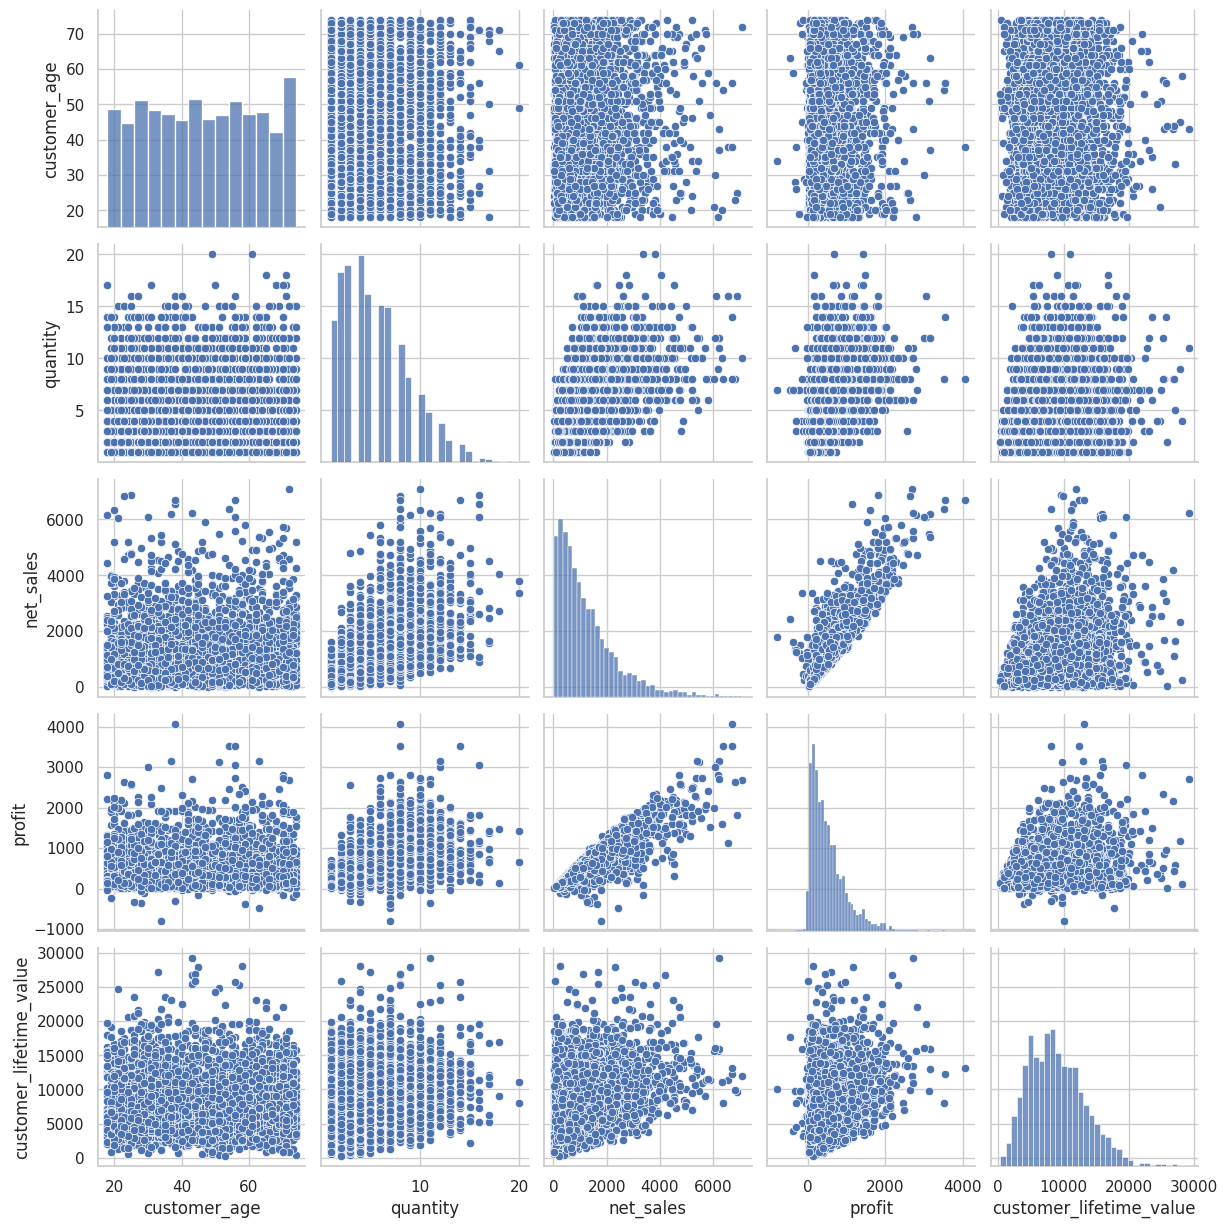

In [16]:

pairplot_columns = [
    "customer_age",
    "quantity",
    "net_sales",
    "profit",
    "customer_lifetime_value"
]

pairplot_columns = [
    col for col in pairplot_columns
    if col in df_clean.columns
]

if len(pairplot_columns) >= 2:

    sample_df = df_clean[pairplot_columns].dropna().sample(
        min(3000, len(df_clean[pairplot_columns].dropna())),
        random_state=42
    )

    sns.pairplot(sample_df)
    plt.show()




# 18. CORRELATION ANALYSIS - PEARSON




--- PEARSON CORRELATION ---
                          customer_age  delivery_days  \
customer_age                       1.0          -0.00   
delivery_days                     -0.0           1.00   
estimated_delivery_days           -0.0           0.92   
customer_rating                   -0.0          -0.16   
quantity                          -0.0           0.00   
gross_sales                        0.0           0.00   
discount_amount                    0.0           0.00   
tax_amount                         0.0          -0.00   
shipping_cost                      0.0          -0.30   
net_sales                          0.0          -0.00   
product_cost                       0.0           0.00   
profit                             0.0          -0.00   
profit_margin_percentage           0.0           0.04   
customer_lifetime_value           -0.0          -0.00   
customer_order_count              -0.0          -0.00   

                          estimated_delivery_days  custome

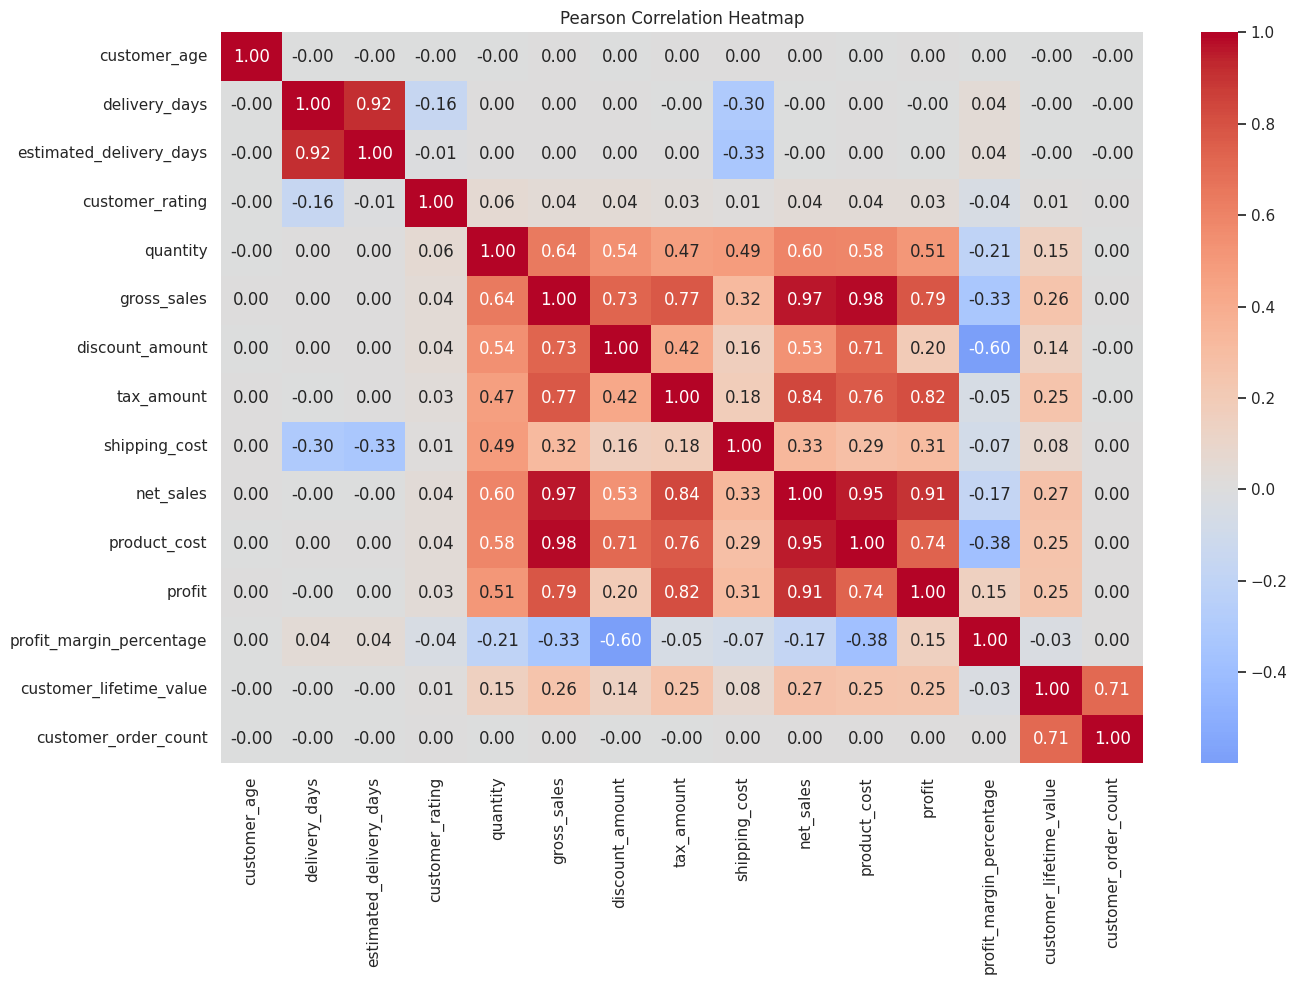

In [18]:


correlation_columns = [
    col for col in important_numeric
    if col in df_clean.columns
]

pearson_corr = df_clean[correlation_columns].corr(
    method="pearson"
)

print("\n--- PEARSON CORRELATION ---")
print(pearson_corr.round(2))

plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()




# 19. SPEARMAN CORRELATION




--- SPEARMAN CORRELATION ---
                          customer_age  delivery_days  \
customer_age                      1.00          -0.00   
delivery_days                    -0.00           1.00   
estimated_delivery_days          -0.00           0.92   
customer_rating                  -0.00          -0.14   
quantity                         -0.00           0.00   
gross_sales                       0.00          -0.00   
discount_amount                   0.00          -0.00   
tax_amount                        0.00          -0.00   
shipping_cost                     0.00          -0.33   
net_sales                         0.00          -0.01   
product_cost                      0.00          -0.00   
profit                            0.00          -0.00   
profit_margin_percentage         -0.00           0.05   
customer_lifetime_value          -0.00          -0.01   
customer_order_count             -0.01          -0.00   

                          estimated_delivery_days  custom

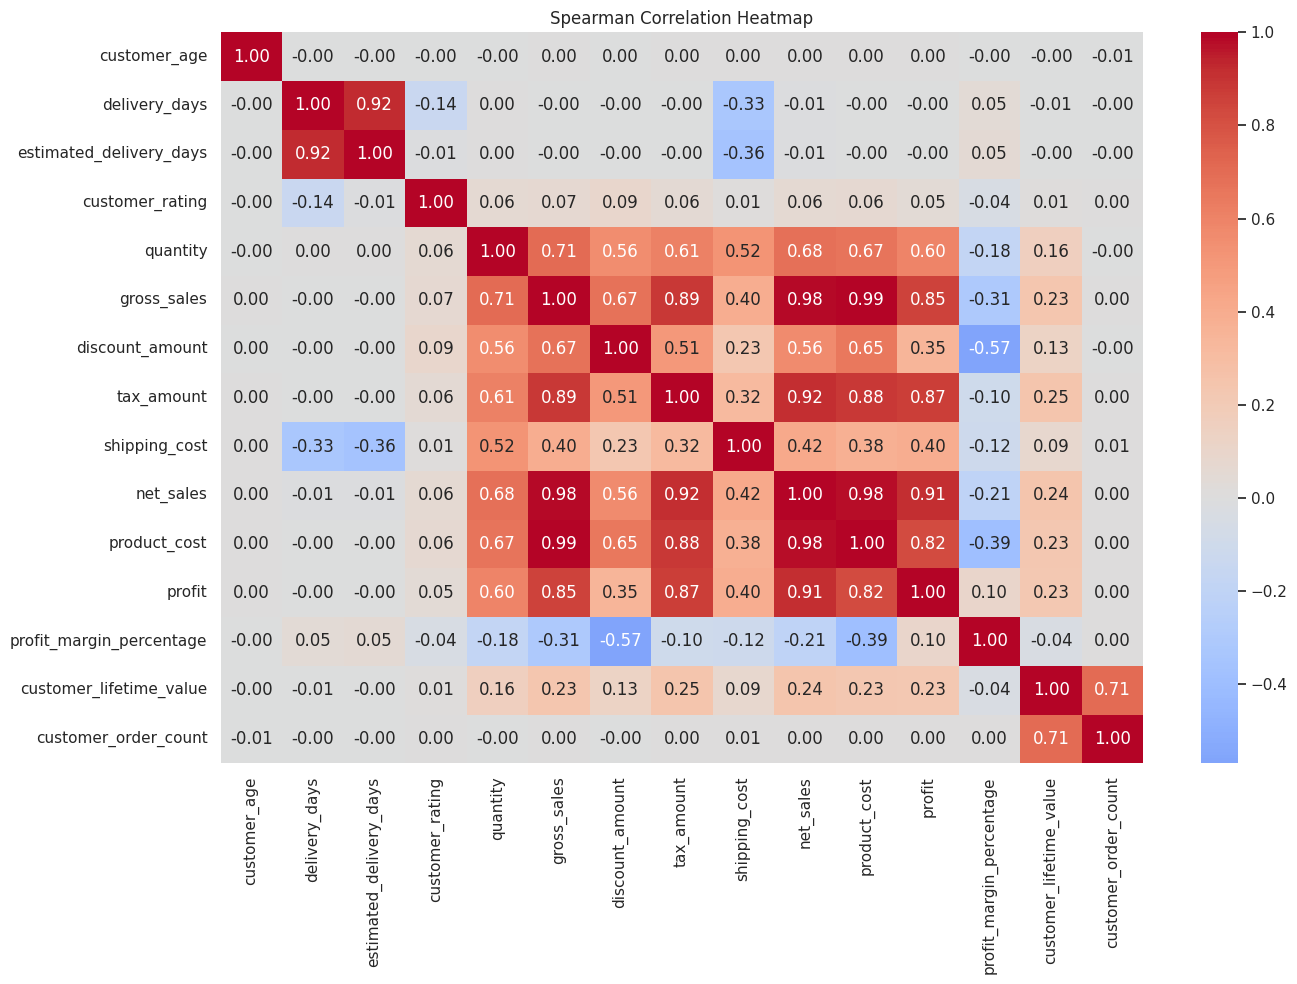

In [19]:


spearman_corr = df_clean[correlation_columns].corr(
    method="spearman"
)

print("\n--- SPEARMAN CORRELATION ---")
print(spearman_corr.round(2))

plt.figure(figsize=(14, 10))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()




# 20. PEARSON VS SPEARMAN COMPARISON



In [20]:



if {"gross_sales", "profit"}.issubset(df_clean.columns):

    pearson_value = df_clean[
        ["gross_sales", "profit"]
    ].corr(method="pearson").iloc[0, 1]

    spearman_value = df_clean[
        ["gross_sales", "profit"]
    ].corr(method="spearman").iloc[0, 1]

    print("\n--- PEARSON VS SPEARMAN ---")
    print("Gross Sales vs Profit")
    print("Pearson correlation :", round(pearson_value, 4))
    print("Spearman correlation:", round(spearman_value, 4))





--- PEARSON VS SPEARMAN ---
Gross Sales vs Profit
Pearson correlation : 0.7852
Spearman correlation: 0.8501


# 21. DISTRIBUTION ANALYSIS



In [21]:


distribution_table = pd.DataFrame({
    "Mean": df_clean[important_numeric].mean(),
    "Median": df_clean[important_numeric].median(),
    "Std_Dev": df_clean[important_numeric].std(),
    "Variance": df_clean[important_numeric].var(),
    "Skewness": df_clean[important_numeric].skew(),
    "Kurtosis": df_clean[important_numeric].kurt()
})

print("\n--- DISTRIBUTION STATISTICS ---")
print(distribution_table.round(3))


# Interpretation helper
print("\n--- SKEWNESS INTERPRETATION ---")

for col in important_numeric:

    skew_value = df_clean[col].skew()

    if skew_value > 1:
        interpretation = "Highly positively/right skewed"
    elif skew_value > 0.5:
        interpretation = "Moderately positively/right skewed"
    elif skew_value < -1:
        interpretation = "Highly negatively/left skewed"
    elif skew_value < -0.5:
        interpretation = "Moderately negatively/left skewed"
    else:
        interpretation = "Approximately symmetric"

    print(f"{col}: {skew_value:.3f} -> {interpretation}")





--- DISTRIBUTION STATISTICS ---
                              Mean    Median   Std_Dev      Variance  \
customer_age                45.863    46.000    16.468  2.711840e+02   
delivery_days                4.558     4.000     2.810  7.896000e+00   
estimated_delivery_days      4.299     4.000     2.594  6.729000e+00   
customer_rating              3.677     3.700     0.484  2.340000e-01   
quantity                     5.615     5.000     3.371  1.136600e+01   
gross_sales               1375.384   995.730  1291.010  1.666706e+06   
discount_amount            237.622   103.285   378.779  1.434739e+05   
tax_amount                 122.463    77.010   140.939  1.986390e+04   
shipping_cost               22.278    19.190    16.023  2.567280e+02   
net_sales                 1282.504   950.760  1169.275  1.367203e+06   
product_cost               708.903   478.955   730.045  5.329657e+05   
profit                     551.322   408.395   516.301  2.665667e+05   
profit_margin_percentage    45.

# 22. KDE DISTRIBUTION



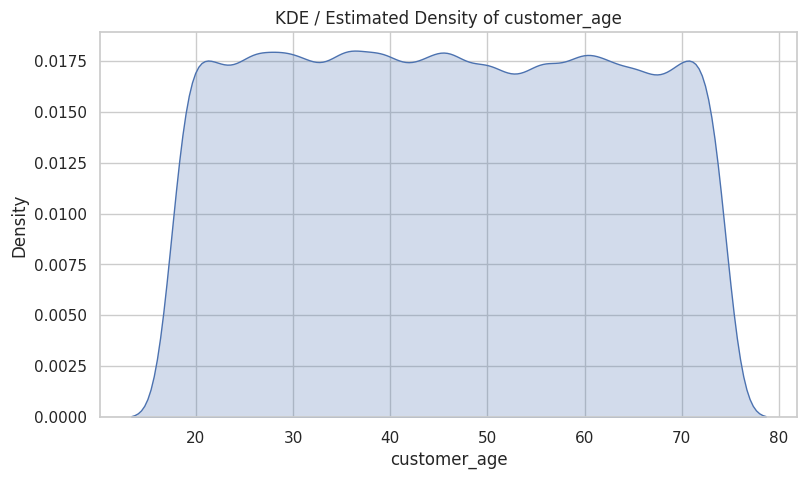

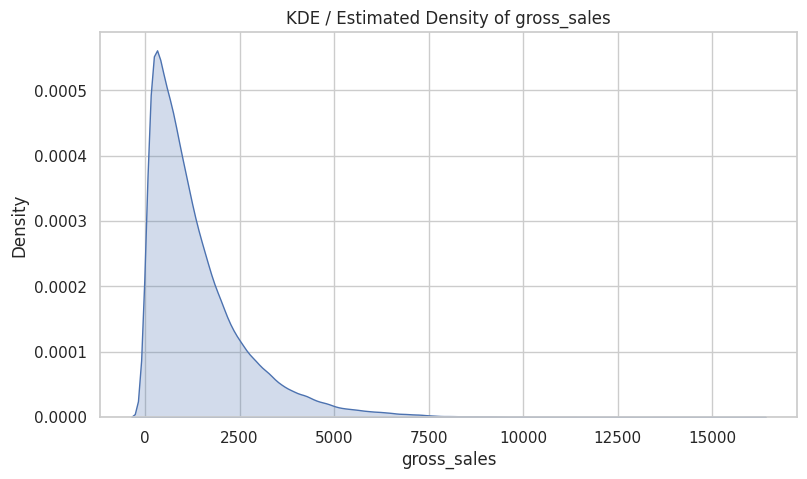

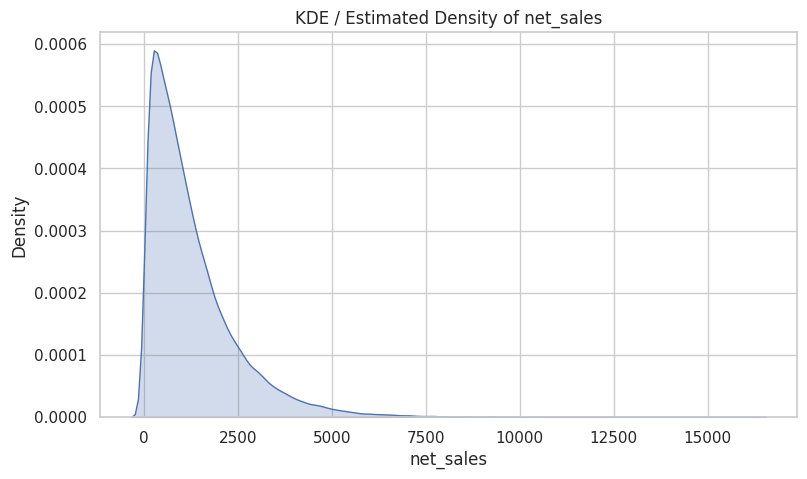

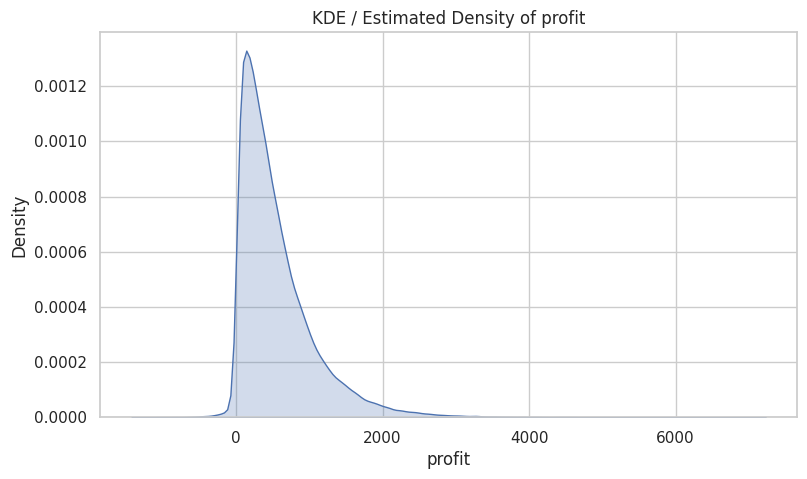

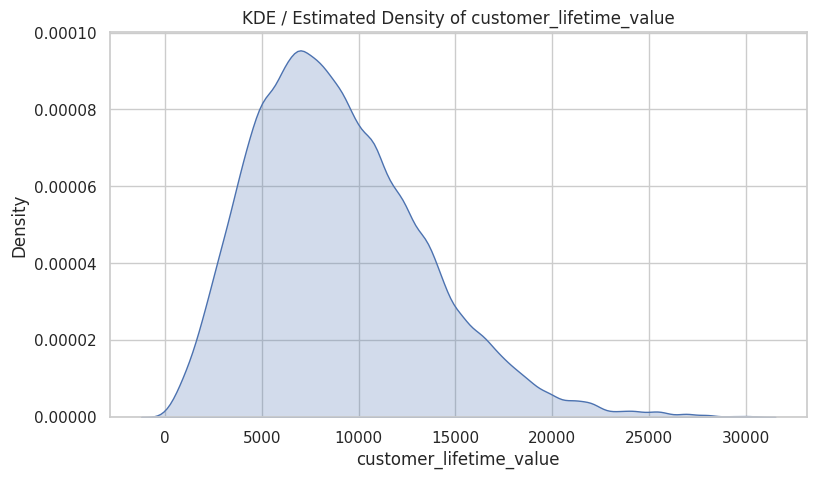

In [22]:


for col in [
    "customer_age",
    "gross_sales",
    "net_sales",
    "profit",
    "customer_lifetime_value"
]:

    if col in df_clean.columns:

        plt.figure(figsize=(9, 5))

        sns.kdeplot(
            data=df_clean,
            x=col,
            fill=True
        )

        plt.title(f"KDE / Estimated Density of {col}")
        plt.show()




# 24. DATA TRANSFORMATION




Transformation created for: gross_sales

Transformation created for: net_sales

Transformation created for: profit

Transformation created for: customer_lifetime_value


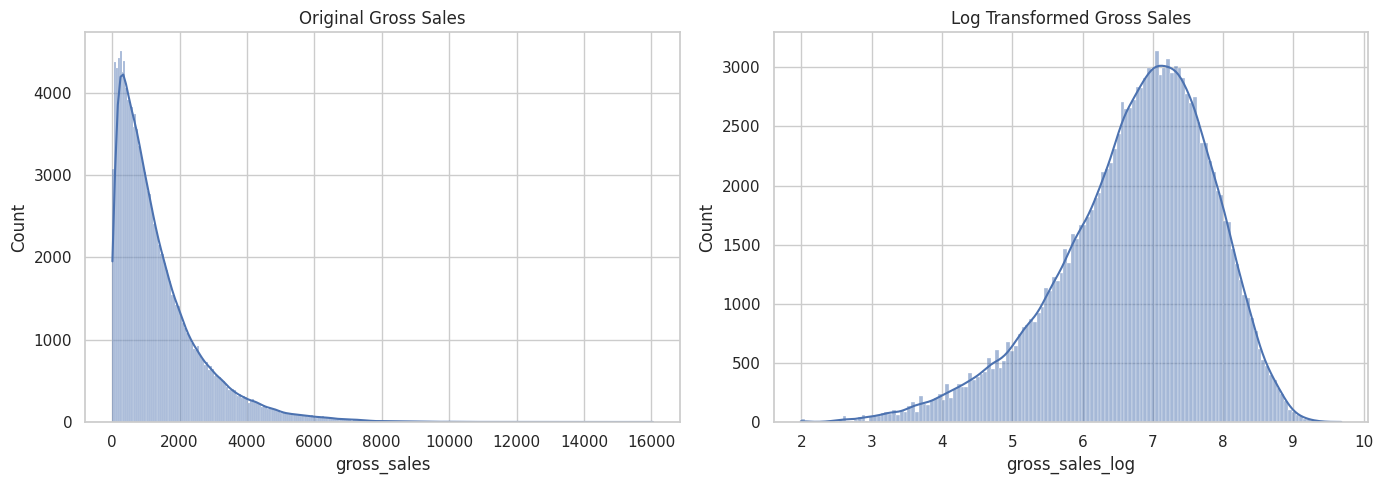

In [23]:


transformation_columns = [
    "gross_sales",
    "net_sales",
    "profit",
    "customer_lifetime_value"
]

for col in transformation_columns:

    if col in df_clean.columns:

        # log1p works with zero values.
        # For negative values, shift the data first.
        minimum_value = df_clean[col].min()

        if minimum_value >= 0:
            df_clean[col + "_log"] = np.log1p(
                df_clean[col]
            )
        else:
            shift = abs(minimum_value) + 1
            df_clean[col + "_log"] = np.log1p(
                df_clean[col] + shift
            )

        print(f"\nTransformation created for: {col}")


# Compare original and transformed distribution
if "gross_sales_log" in df_clean.columns:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        df_clean["gross_sales"].dropna(),
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title("Original Gross Sales")

    sns.histplot(
        df_clean["gross_sales_log"].dropna(),
        kde=True,
        ax=axes[1]
    )
    axes[1].set_title("Log Transformed Gross Sales")

    plt.tight_layout()
    plt.show()




# 25. GROUP-WISE ANALYSIS



In [26]:


print("\n--- GROUP-WISE ANALYSIS ---")

if {"customer_segment", "net_sales"}.issubset(df_clean.columns):

    segment_summary = df_clean.groupby(
        "customer_segment"
    ).agg(
        Average_Net_Sales=("net_sales", "mean"),
        Median_Net_Sales=("net_sales", "median"),
        Total_Net_Sales=("net_sales", "sum"),
        Average_Profit=("profit", "mean"),
        Number_of_Orders=("order_id", "count")
    ).sort_values(
        "Total_Net_Sales",
        ascending=False
    )

    print(segment_summary)


if {"sales_channel", "net_sales"}.issubset(df_clean.columns):

    channel_summary = df_clean.groupby(
        "sales_channel"
    ).agg(
        Average_Net_Sales=("net_sales", "mean"),
        Total_Net_Sales=("net_sales", "sum"),
        Average_Profit=("profit", "mean"),
        Orders=("order_id", "count")
    ).sort_values(
        "Total_Net_Sales",
        ascending=False
    )

    print("\n--- SALES CHANNEL SUMMARY ---")
    print(channel_summary)





--- GROUP-WISE ANALYSIS ---
                  Average_Net_Sales  Median_Net_Sales  Total_Net_Sales  \
customer_segment                                                         
Consumer                1285.115658           952.425      97201007.90   
Premium                 1274.097569           946.825      44269794.13   
VIP                     1282.737322           960.150      17903164.81   
Business                1289.126581           943.030      17760296.90   

                  Average_Profit  Number_of_Orders  
customer_segment                                    
Consumer              566.129753             75636  
Premium               523.160300             34746  
VIP                   527.789115             13957  
Business              564.892595             13777  

--- SALES CHANNEL SUMMARY ---
               Average_Net_Sales  Total_Net_Sales  Average_Profit  Orders
sales_channel                                                            
Mobile App           1280.501

# 26. TIME-SERIES EDA



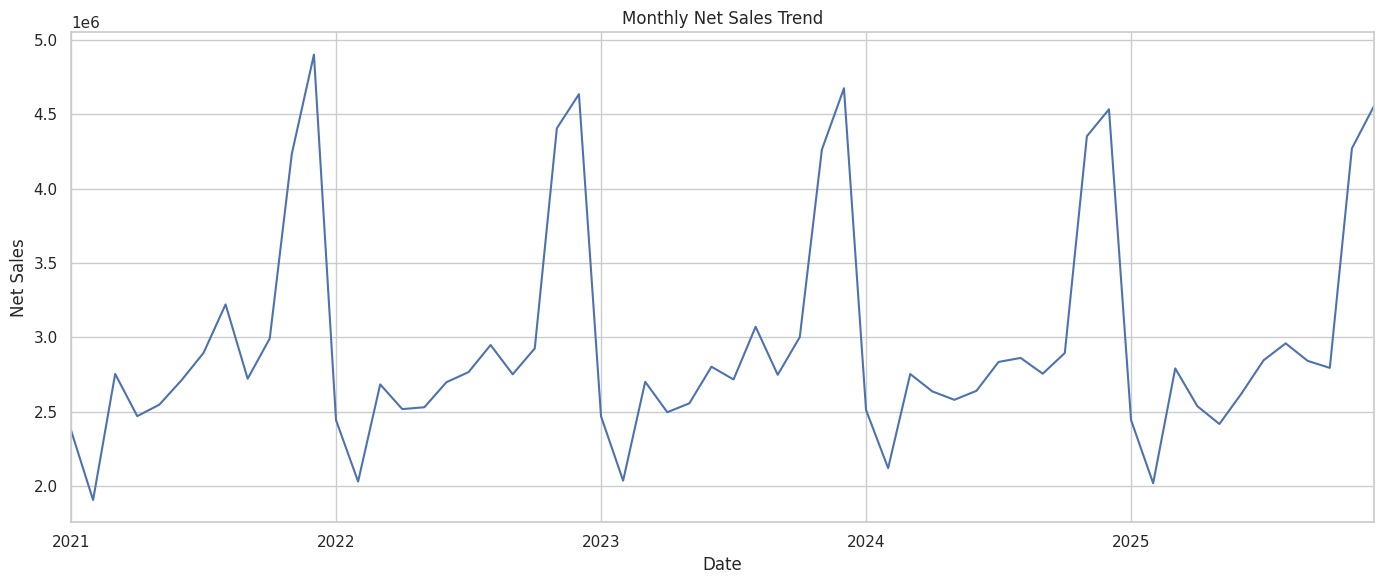

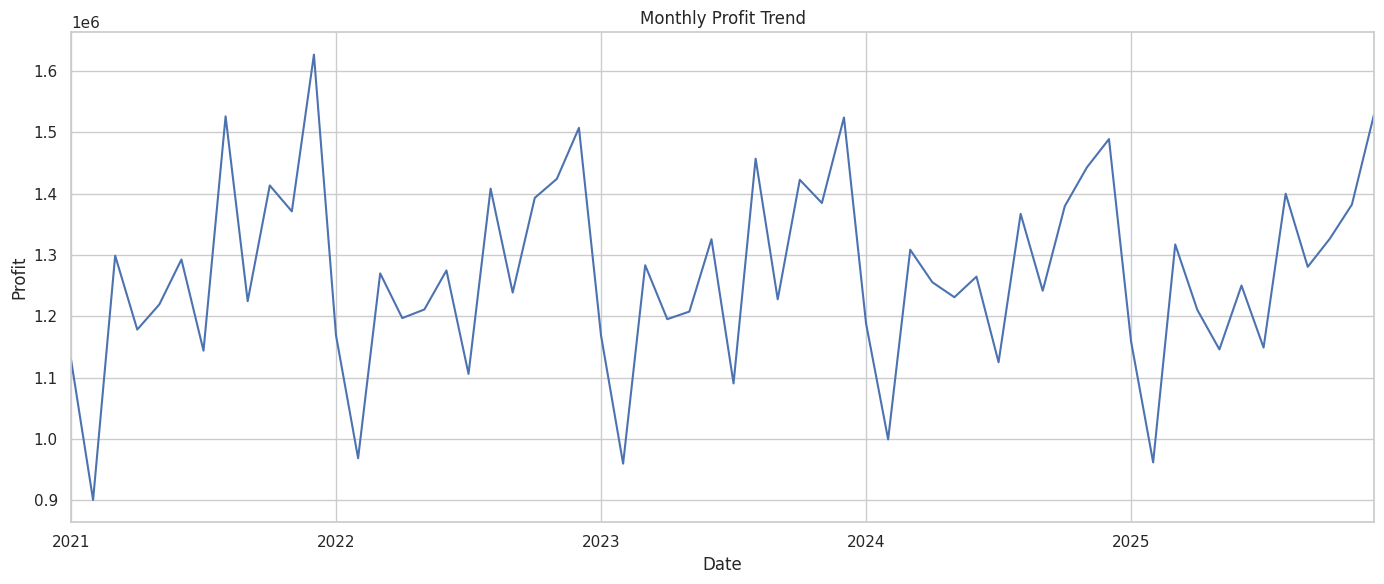

In [25]:


if {"order_date", "net_sales"}.issubset(df_clean.columns):

    monthly_sales = (
        df_clean
        .set_index("order_date")
        .resample("ME")["net_sales"]
        .sum()
    )

    plt.figure(figsize=(14, 6))
    monthly_sales.plot()
    plt.title("Monthly Net Sales Trend")
    plt.xlabel("Date")
    plt.ylabel("Net Sales")
    plt.tight_layout()
    plt.show()


if {"order_date", "profit"}.issubset(df_clean.columns):

    monthly_profit = (
        df_clean
        .set_index("order_date")
        .resample("ME")["profit"]
        .sum()
    )

    plt.figure(figsize=(14, 6))
    monthly_profit.plot()
    plt.title("Monthly Profit Trend")
    plt.xlabel("Date")
    plt.ylabel("Profit")
    plt.tight_layout()
    plt.show()




# 31. PLOTLY VISUALIZATIONS

In [27]:

if {
    "gross_sales",
    "profit",
    "customer_segment"
}.issubset(df_clean.columns):

    plot_df = df_clean.sample(
        min(5000, len(df_clean)),
        random_state=42
    )

    fig = px.scatter(
        plot_df,
        x="gross_sales",
        y="profit",
        color="customer_segment",
        hover_data=[
            "sales_channel",
            "customer_age",
            "net_sales"
        ],
        title="Interactive Gross Sales vs Profit"
    )

    fig.show()


if {
    "order_date",
    "net_sales"
}.issubset(df_clean.columns):

    monthly = (
        df_clean
        .set_index("order_date")
        .resample("ME")["net_sales"]
        .sum()
        .reset_index()
    )

    fig = px.line(
        monthly,
        x="order_date",
        y="net_sales",
        title="Interactive Monthly Net Sales Trend"
    )

    fig.show()




# 32. FINAL INSIGHTS



In [28]:

print("\n")
print("=" * 70)
print("FINAL EDA INSIGHTS")
print("=" * 70)

print("\n1. DATASET SIZE")
print(
    f"The dataset contains {df_clean.shape[0]:,} rows "
    f"and {df_clean.shape[1]:,} columns after duplicate handling."
)

print("\n2. DUPLICATES")
print(
    f"Duplicate rows found in original dataset: {duplicate_count:,}"
)

print("\n3. MISSING VALUES")
total_missing = df.isnull().sum().sum()

print(
    f"Total missing values in the original dataset: "
    f"{total_missing:,}"
)

print(
    "Missing values should be treated according to their meaning. "
    "They should not automatically be deleted or replaced."
)

if "customer_age" in df_clean.columns:
    print("\n4. CUSTOMER AGE")
    print(
        f"Average customer age: "
        f"{df_clean['customer_age'].mean():.2f}"
    )
    print(
        f"Median customer age: "
        f"{df_clean['customer_age'].median():.2f}"
    )

if "net_sales" in df_clean.columns:
    print("\n5. NET SALES")
    print(
        f"Average net sales per order: "
        f"{df_clean['net_sales'].mean():.2f}"
    )
    print(
        f"Total net sales: "
        f"{df_clean['net_sales'].sum():,.2f}"
    )

if "profit" in df_clean.columns:
    print("\n6. PROFIT")
    print(
        f"Average profit per order: "
        f"{df_clean['profit'].mean():.2f}"
    )

    print(
        f"Orders with negative profit: "
        f"{(df_clean['profit'] < 0).sum():,}"
    )

if "customer_segment" in df_clean.columns:
    print("\n7. CUSTOMER SEGMENT DISTRIBUTION")
    print(
        df_clean["customer_segment"]
        .value_counts()
    )

if "sales_channel" in df_clean.columns:
    print("\n8. SALES CHANNEL DISTRIBUTION")
    print(
        df_clean["sales_channel"]
        .value_counts()
    )






FINAL EDA INSIGHTS

1. DATASET SIZE
The dataset contains 138,116 rows and 56 columns after duplicate handling.

2. DUPLICATES
Duplicate rows found in original dataset: 0

3. MISSING VALUES
Total missing values in the original dataset: 573,828
Missing values should be treated according to their meaning. They should not automatically be deleted or replaced.

4. CUSTOMER AGE
Average customer age: 45.86
Median customer age: 46.00

5. NET SALES
Average net sales per order: 1282.50
Total net sales: 177,134,263.74

6. PROFIT
Average profit per order: 551.32
Orders with negative profit: 1,296

7. CUSTOMER SEGMENT DISTRIBUTION
customer_segment
Consumer    75636
Premium     34746
VIP         13957
Business    13777
Name: count, dtype: int64

8. SALES CHANNEL DISTRIBUTION
sales_channel
Mobile App      55318
Website         48237
Marketplace     20698
Social Media    13863
Name: count, dtype: int64


# Conclusion



In [30]:


print("""
MAIN STEPS COMPLETED:
✓ Dataset loading
✓ Dataset structure
✓ Duplicate analysis
✓ Missing-value analysis
✓ Data consistency checks
✓ Date/time processing
✓ Univariate analysis
✓ Outlier detection
✓ Bivariate analysis
✓ Multivariate analysis
✓ Pearson correlation
✓ Spearman correlation
✓ Distribution analysis
✓ KDE analysis
✓ Data transformation
✓ Group-wise analysis
✓ Time-series analysis
✓ Plotly analysis
✓ Final insights

""")



MAIN STEPS COMPLETED:
✓ Dataset loading
✓ Dataset structure
✓ Duplicate analysis
✓ Missing-value analysis
✓ Data consistency checks
✓ Date/time processing
✓ Univariate analysis
✓ Outlier detection
✓ Bivariate analysis
✓ Multivariate analysis
✓ Pearson correlation
✓ Spearman correlation
✓ Distribution analysis
✓ KDE analysis
✓ Data transformation
✓ Group-wise analysis
✓ Time-series analysis
✓ Plotly analysis
✓ Final insights




# Final Conclusion

*   The dataset contains both numerical and categorical variables related to customers, orders, sales and delivery.
*   Missing values were found in several columns, especially return, review and delivery-related fields, and their meaning was considered before handling them.

*   Duplicate records and inconsistent values were checked during data cleaning.
*   Histograms and box plots helped identify data distributions, skewness and outliers in variables such as sales, profit and customer-related attributes.

*   Pearson and Spearman correlation were used to identify relationships between numerical variables.
*   Group-wise and time-based analysis helped understand sales, profit and customer behaviour across different segments and periods.

Overall, EDA helped identify the main patterns, relationships, missing data and unusual observations in the e-commerce dataset.







Final Conclusion

The EDA provided a clear understanding of the e-commerce dataset by examining its structure, data quality, distributions, outliers, relationships and trends. Missing values and unusual observations were identified, while statistical and visual analysis helped understand customer, sales and profit patterns. This analysis can be used as a foundation for further statistical analysis and machine learning.
